In [52]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

- 2013년이후 전국 아파트분양가격
- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [1]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지
# 다른 폰트를 기본으로 하려면
# file_path = 'data/font/적용할 폰트.ttf'
# fontproperties = FontProperties(fname=file_path, size=15)

from matplotlib.font_manager import FontProperties # 대문자 시작은 클래스
# font_path = 'C:/Users/mbc1/AppData/Local/Microsoft/Windows/Fonts/MaruBuri-SemiBold.ttf'
# font_Manager.addfont(font_path)
# font_prop = FontProperties(fname=font_path, size=15)
# font_name = font_prop.get_name()
# plt.rc('font', family='MaruBuri-SemiBold.ttf') # 윈도우즈
# plt.rc('font', size=20)
# plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색한 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [2]:
pd.read_csv?

In [3]:
df_first = pd.read_csv(r'C:/ai/downloads/sharedata/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [4]:
pd.options.display.max_columns = 22 # 최대 display 가능한 열수 변경

In [5]:
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
12,전북,6282,6281,5946,5966,6277,6306,6351,6319,6436,6719,6581,6583,6583,6583,6583,6542,6551,6556,6601,6750,6580


In [6]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [7]:
df_first.set_index('지역')

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,8038,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,8627,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,10397,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,8527,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


In [8]:
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

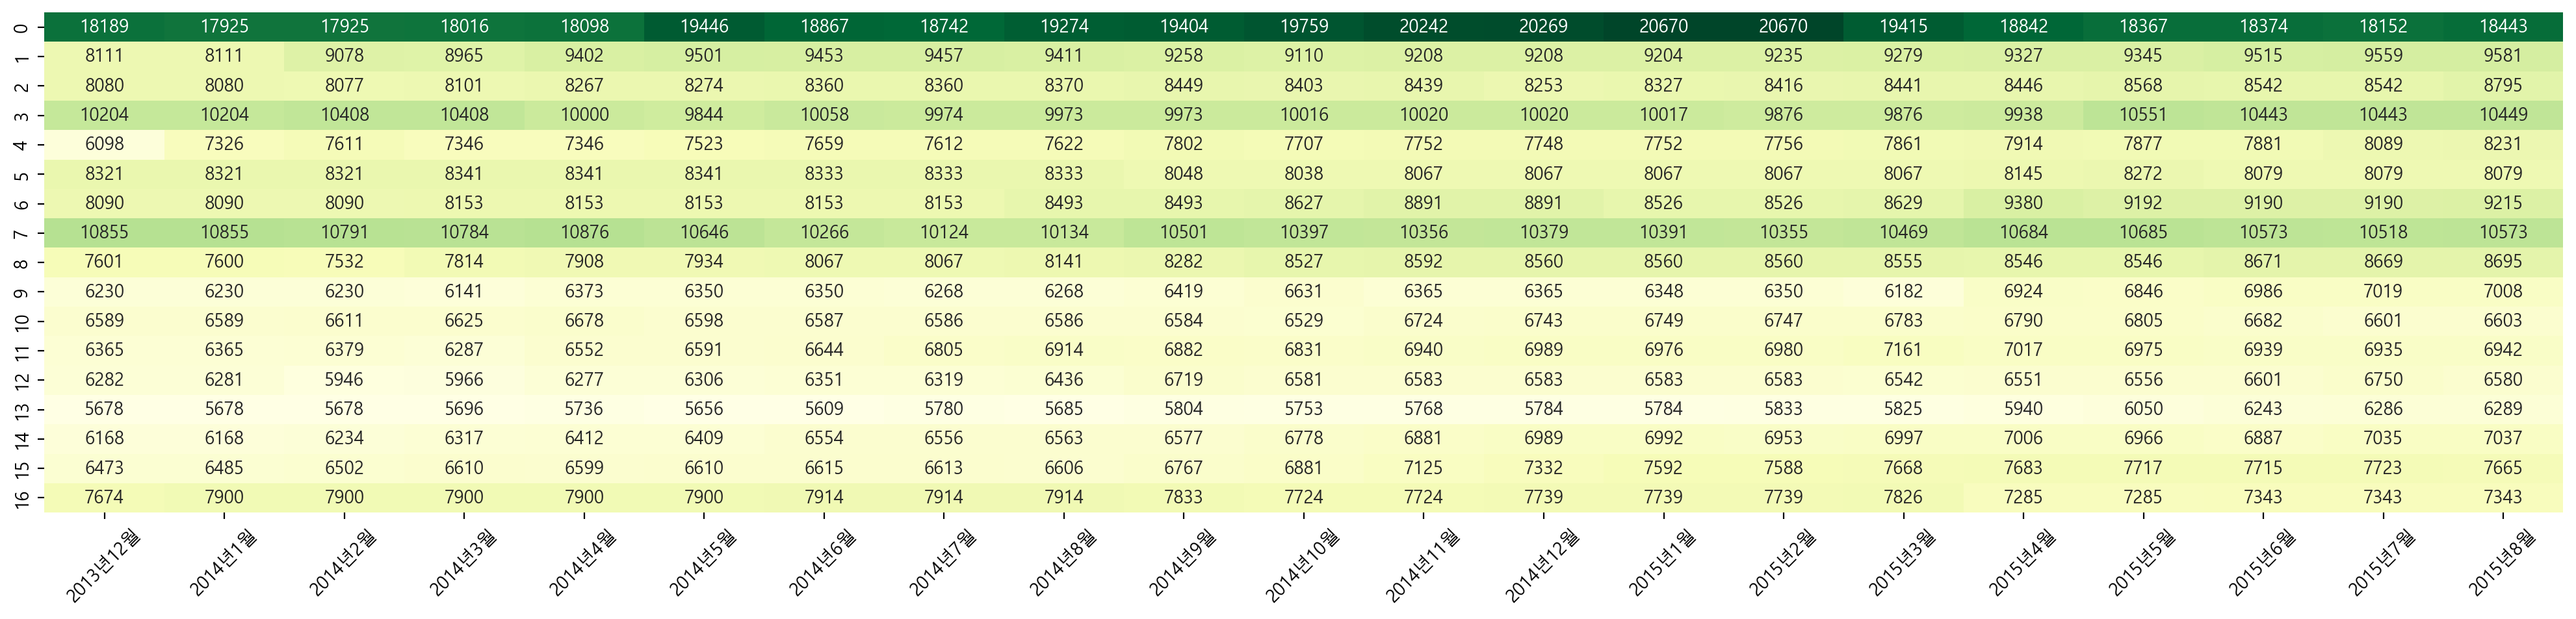

In [9]:
plt.figure(figsize=(25,5))
sns.heatmap(df_first.iloc[:, 1:], annot=True, fmt='d', cmap='YlGn', cbar=False)
plt.xticks(rotation=45)
plt.ylabel(None)
plt.show()

## (2) 2015이후 데이터 분양가격에 간헐적으로 comma(,) 추가하여 csv로 출력

In [10]:
import numpy as np
df  = pd.read_csv(r'C:\ai\downloads\sharedata\분양가격\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')

for c in [col for col in df.columns if col.startswith("2015년")] :
    df[c] = df[c].map(
        lambda x: format(int(x),",") if np.random.rand() < 0.5 else x)

result = df.sample(n=5).sample(n=5, axis=1)
cols = [c for c in df.columns if c in result.columns]
result = result.sort_index()[cols] # 여기서 [cols] -> 열을 cols 리스트 순서대로 선택
result.to_csv(r'C:\ai\downloads\sharedata\분양가격\분양가격_랜덤5행5열.csv', index=False, encoding='cp949')
result

,2014년3월,2014년12월,2015년2월,2015년6월,2015년7월
1,8965,9208,"9,235",9515,9559
2,8101,8253,8416,"8,542","8,542"
11,6287,6989,"6,980","6,939","6,935"
14,6317,6989,"6,953",6887,7035
15,6610,7332,7588,7715,7723


In [11]:
# isna(), isnull() - 결측치 여부
# notnull(), notna() - 결측치가 아닌지 여부


In [12]:
# 분양가격(제곱미터당 천원)가 결측치인 행 상위2개


In [13]:
# 분양가격(제곱미터당 천원) 컬럼의 type을 float64로 타입 변환 : astype(), pd.to_numeric()


In [14]:
# 분양가격(제곱미터당 천원) 컬럼이 space인 행


In [15]:
# 분양가격이 nan이거나 space면 0, 그외 분양가격의 문자자리수를 return하는 함수
def get_pricelen(row):
    pass


In [16]:
# 2020년전 데이터 흉내내기 위한 함수  : nan, ' ', '  ', '5123', '5,123'
def comma_append(row):
    pass

In [17]:
# 간헐적으로 평당분양가에 ,가 있거나 np.nan이 있거나 space가 있는 데이터 csv로 백업

## (3) 이후 데이터는 df_last 변수에 담아 탐색

In [18]:
df_last = pd.read_csv(r'C:\ai\downloads\sharedata\분양가격\주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv', encoding='cp949')
df_last.shape

(10880, 5)

In [19]:
df_last.tail(3)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN
10879,제주,전용면적 102제곱미터초과,2026,5,4350


In [20]:
# 데이터 요약하기
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [21]:
df_last['분양가격(제곱미터당 천원)'].describe()

count     10035
unique     3637
top            
freq         95
Name: 분양가격(제곱미터당 천원), dtype: object

# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [22]:
# 열별 결측치 갯수
df_last.isna().sum()

지역명                 0
규모구분                0
연도                  0
월                   0
분양가격(제곱미터당 천원)    845
dtype: int64

In [23]:
# 결측치인 행 : 368, ~...
print('결측치인 행 :', df_last[df_last['분양가격(제곱미터당 천원)'].isna()].shape[0])
print('결측치인 행 :', len(df_last[df_last['분양가격(제곱미터당 천원)'].isna()]))

결측치인 행 : 845
결측치인 행 : 845


In [24]:
# 열별 결측치를 제외한 갯수


# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정 후, 형변환
## (3) df_last['분양가격(제곱미터)']*3.3

In [25]:
# df_last['분양가격(제곱미터당 천원)'].astype('float64')
# pd.to_numeric(문자열이나 다른 자료형을 숫자형(int, float)으로 변환하는 함수)
temp = pd.to_numeric(df_last['분양가격(제곱미터당 천원)'], errors='coerce').isna() # errors='변환 중 오류가 발생했을 때 어떻게 처리할 것인지를 지정하는 옵션'
nanidx = temp[temp.isna()].index
nanidx
# 973 = 845개(원래 nan) + 128개(' ', ',' , '-')

Int64Index([], dtype='int64')

In [26]:
# 위에 변경값을 입력하지않고 평균을 구하기 위해 .mean을 사용하면 숫자열이 아닌 문자열이 있기때문에 안구해짐.
# df_last['분양가격(제곱미터당 천원)']==' ' 인 행
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()==''].shape[0] # .strip() 문자열의 앞뒤 공백을 지워주는 함수

126

In [27]:
df_last.loc[nanidx, '분양가격(제곱미터당 천원)'].unique()

array([], dtype=object)

In [28]:
# df_last[df_last['분양가격(제곱미터당 천원)']=='-']     '-' 인행 : 8861행, 8863행
df_last[df_last['분양가격(제곱미터당 천원)']=='-']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
8861,대구,전용면적 60제곱미터이하,2024,6,-
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-


### apply
- apply(func, axis) : 1차원, 2차원(axis지정. 기본값0=열단위작업ㅇㅇㅇ)

In [29]:
# 콤마가 있는 문자에서 콤마 없애기 방법
temp = '12,523'
temp.replace(',','')

'12523'

In [30]:
df_last.loc[368]

지역명                                    광주
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2016
월                                       2
분양가격(제곱미터당 천원)                        NaN
Name: 368, dtype: object

In [31]:
# 분양가격 컬럼에 콤마(,)가 있는 경우 콤마(,)를 제거('5,123' -> '5123')
# 공백문자가 있는 경우 np.nan로 바꾸는 함수
def commadrop(row):
    row = row.copy()
    price = row['분양가격(제곱미터당 천원)']
    # np.isnan(스칼라값) : 값이 숫자일 경우만 에러나지 않고, np.nan 결측치 여부 반환
    # pd.isna(스칼라값), pd.isnull(값) : 값의 타입에 상관없이 np.nan과 None인지 여부 반환
    if pd.isna(price): # 결측치인지 여부
        row['제곱미터당분양가격'] = np.nan
    elif price.strip() == '' or price=='-' : # space거나 -이면 결측치
        row['제곱미터당분양가격'] = np.nan
    elif price.find(',') != -1: # price에 ,가 포함되었는지
        row['제곱미터당분양가격'] = float(price.replace(',',''))
    else:
        row['제곱미터당분양가격'] = float(price)
    return row
commadrop(df_last.loc[0]) # float로 변환된 수
commadrop(df_last.loc[28]) # 공백문자의 경우 nan
commadrop(df_last.loc[368]) # nan의 경우 nan
commadrop(df_last.loc[8863]) # -의 경우 nan

지역명                                    대구
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2024
월                                       6
분양가격(제곱미터당 천원)                          -
제곱미터당분양가격                             NaN
Name: 8863, dtype: object

In [32]:
# 공백문자는 결측치로, 콤마는 제거하기를 모든 행에 적용
df_last = df_last.apply(commadrop, axis=1)
df_last.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),제곱미터당분양가격
0,서울,모든면적,2015,10,5841,5841.0
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0


In [33]:
df_last[['분양가격(제곱미터당 천원)', '제곱미터당분양가격']].isna().sum()

분양가격(제곱미터당 천원)    845
제곱미터당분양가격         973
dtype: int64

### map
- map(func) : 1차원

In [34]:
df_last.drop(['제곱미터당분양가격'], axis=1, inplace=True)
df_last.sample(1)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
9501,전남,전용면적 60제곱미터이하,2025,1,4119


In [35]:
# 결측치->결측치 return, 공백문자->결측치 return, '3,198' -> 3198 return, '3198'->3198 return,  
def commadrop2(price):
    if pd.isna(price): # 결측치인지 여부
        return np.nan
    elif price.strip() == '' or price=='-' : # space거나 -이면 결측치
        return np.nan
    elif price.find(',') != -1: # price에 ,가 포함되었는지
        return float(price.replace(',',''))
    else:
        return float(price)

commadrop2(df_last.loc[0, '분양가격(제곱미터당 천원)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_last.loc[28, '분양가격(제곱미터당 천원)']) # 공백문자를 nan
commadrop2(df_last.loc[368, '분양가격(제곱미터당 천원)']) # nan을 nan
commadrop2(df_last.loc[8863, '분양가격(제곱미터당 천원)']) # -를 nan

nan

- apply(함수, axis) : 1차원, 2차원(axis 지정. axis기본값0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소들에 함수를 적용)

In [36]:
#df_last['분양가격(제곱미터)'].apply(commadrop2)
df_last['제곱미터당분양가격'] = df_last['분양가격(제곱미터당 천원)'].map(commadrop2)
df_last.iloc[8863:8866]

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),제곱미터당분양가격
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-,NaN
8864,대구,전용면적 102제곱미터초과,2024,6,5593,5593.0
8865,광주,모든면적,2024,6,5471,5471.0


### apply나 map 사용 안하기

In [37]:
pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''), errors='coerce').isna().sum()

973

In [38]:
df_last['제곱미터당분양가격'] = pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''), errors='coerce')
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 510.1+ KB


In [39]:
# 형변환 후 평당분양가격(제곱미터당분양가격*3.3)
df_last['평당분양가격'] = df_last['제곱미터당분양가격']*3.3
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
 6   평당분양가격          9907 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 595.1+ KB


In [40]:
df_last[['제곱미터당분양가격', '평당분양가격']].describe() # 요약 통계량

,제곱미터당분양가격,평당분양가격
count,9907.000000,9907.000000
mean,4291.544867,14162.098062
std,2125.581720,7014.419675
min,1868.000000,6164.400000
25%,2872.000000,9477.600000
50%,3798.000000,12533.400000
75%,4940.500000,16303.650000
max,22713.000000,74952.900000


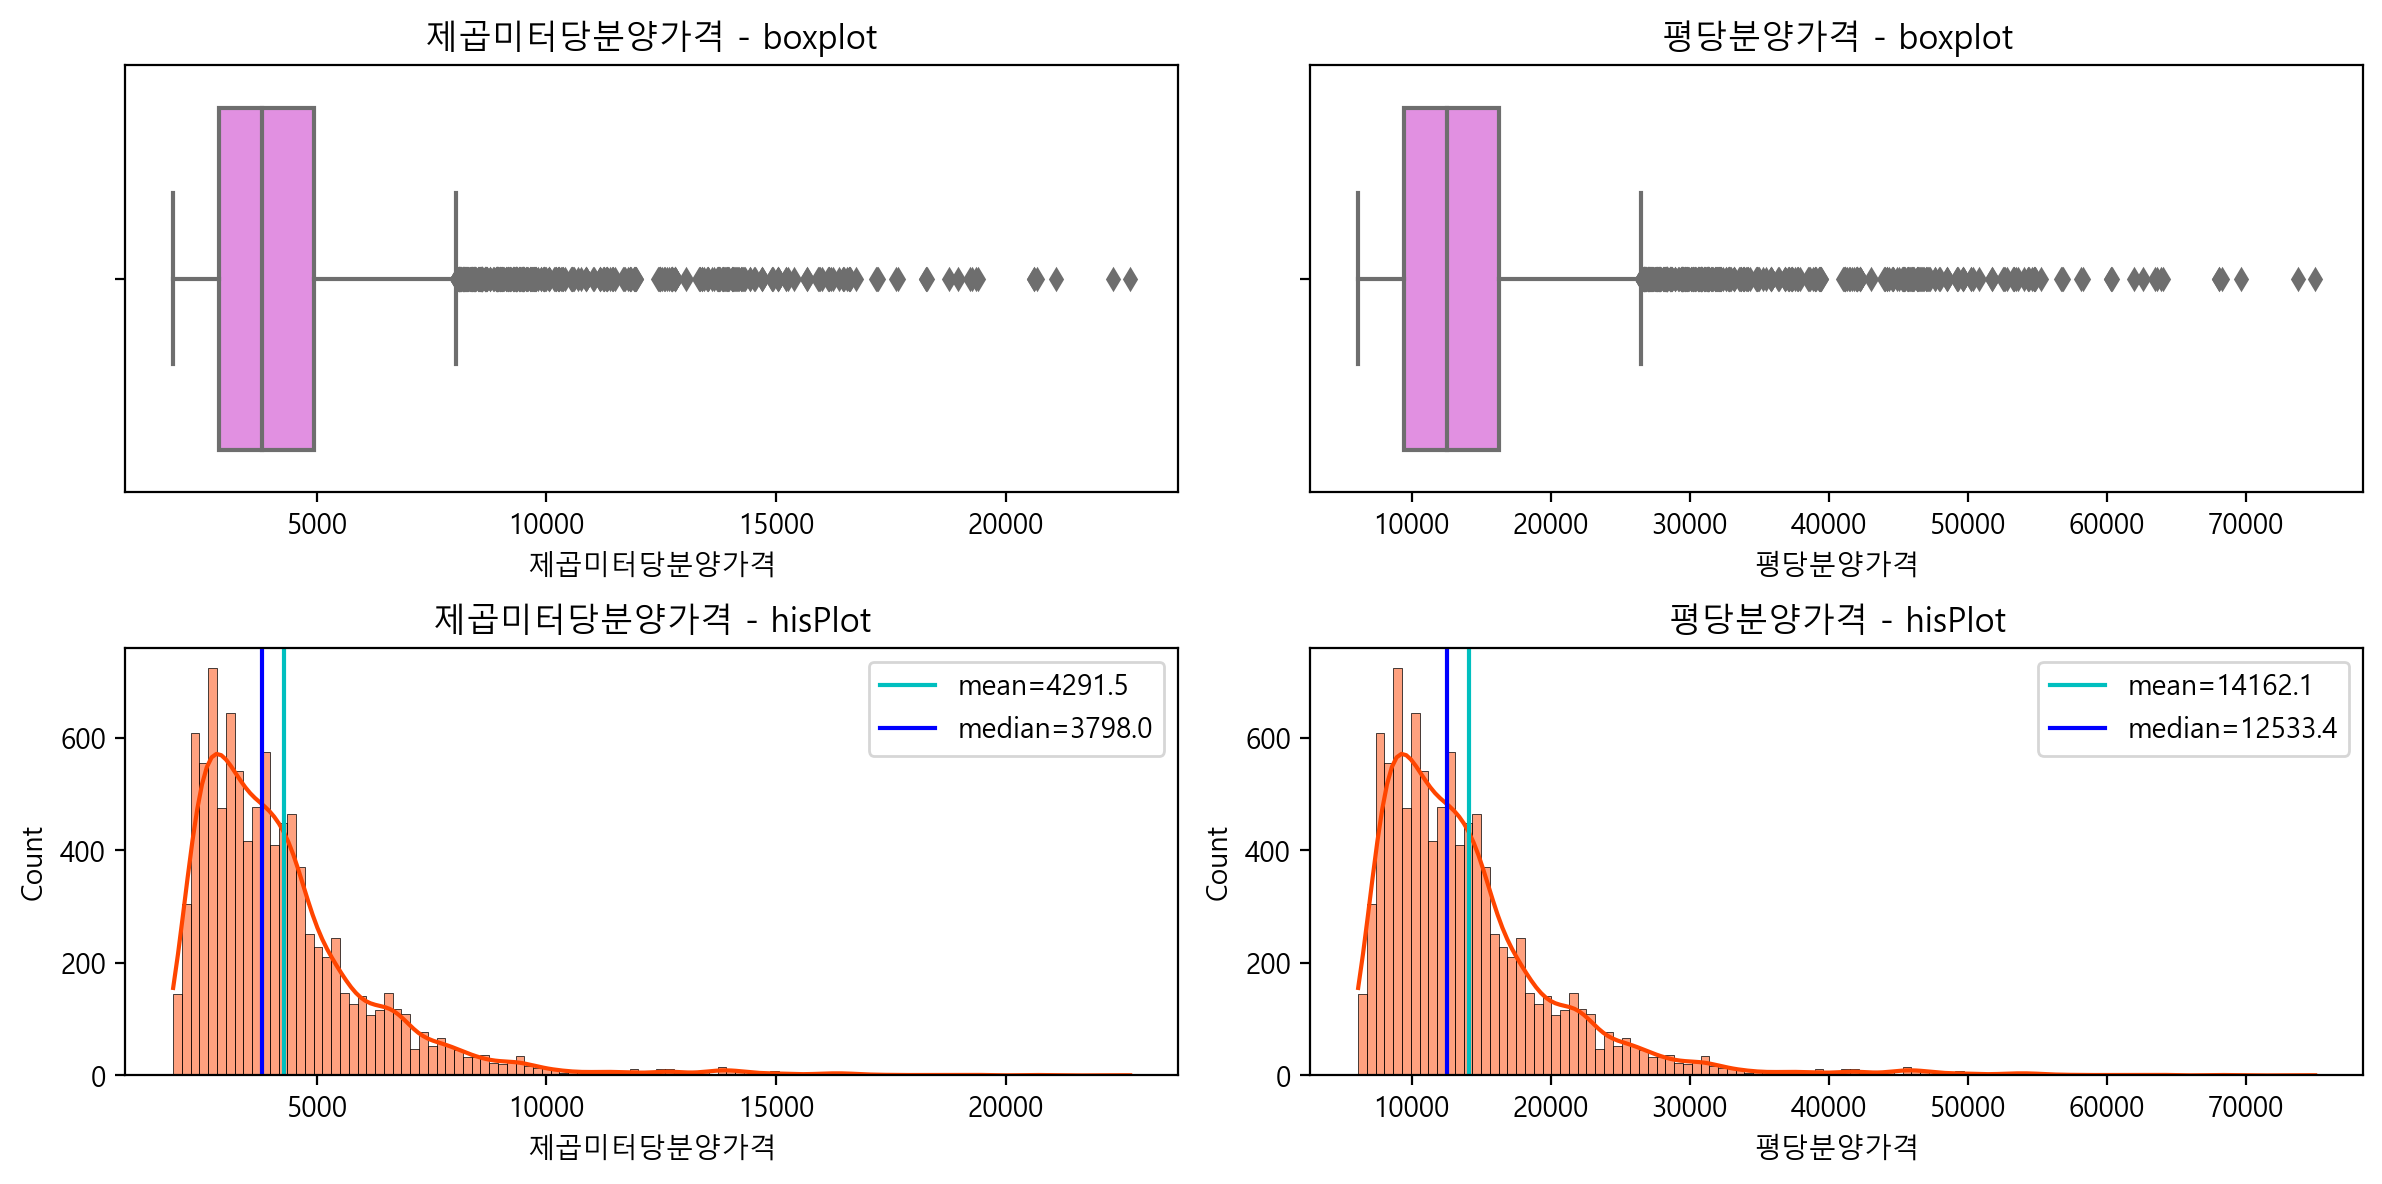

In [41]:
cols = ['제곱미터당분양가격', '평당분양가격']
fig, axes = plt.subplots(nrows=2, ncols=len(cols), figsize=(12,6))
for i, col in enumerate(cols):
    # 0행 boxplot
    sns.boxplot(data=df_last, x=col, ax=axes[0, i], color='violet')
    axes[0,i].set_title(f'{col} - boxplot')
    # 1행 hisplot
    sns.histplot(df_last[col], ax=axes[1, i], color='orangered', kde=True)
    axes[1,i].set_title(f'{col} - hisPlot')
    # 평균(mean)과 중위수(median)를 histplot 표시
    mean_val = df_last[col].mean()
    median_val = df_last[col].median()
    axes[1, i].axvline(mean_val, color='c', label=f'mean={mean_val:.1f}')
    axes[1, i].axvline(median_val, color='b', label=f'median={median_val:.1f}')
    axes[1, i].legend()
plt.tight_layout()

In [42]:
# 왜도(skewness) : 분포가 좌우로 얼마나 비대칭인지를 수치로 나타내는 지표
# 왜도 = 0 : 좌우대칭 / |왜도| < 0.5 : 거의 대칭
# 왜도 > 0 : 오른쪽 꼬리 긴 분포(mean > median)
# 왜도 < 0 : 왼쪽 꼬리 긴 분포 (mean < median)
df_last['제곱미터당분양가격']

0        5841.0
1        5652.0
2        5882.0
3        5721.0
4        5879.0
          ...  
10875    4473.0
10876       NaN
10877    4485.0
10878       NaN
10879    4350.0
Name: 제곱미터당분양가격, Length: 10880, dtype: float64

# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

In [43]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
 6   평당분양가격          9907 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 595.1+ KB


In [44]:
df_last['규모구분'].unique()

array(['모든면적', '전용면적 60제곱미터이하', '전용면적 60제곱미터초과 85제곱미터이하',
       '전용면적 85제곱미터초과 102제곱미터이하', '전용면적 102제곱미터초과'], dtype=object)

In [45]:
# 전용면적 60제곱미터초과 85제곱미터이하 => 60m²~85m²
# ² : alt 누른 상태로 우측 숫자 키패드 0178 입력후에 alt 떼기
# 전용면적 60제곱미터이하 -> 65m²
# 전용면적 102제곱미터초과 -> 102m²~
df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적','').str.replace('이하','').str.replace('제곱미터', 'm²')
df_last['전용면적'] = df_last['전용면적'].str.replace('초과', '~').str.replace(' ', '')
df_last['전용면적'].unique()

array(['모든면적', '60m²', '60m²~85m²', '85m²~102m²', '102m²~'], dtype=object)

In [46]:
print(df_last['전용면적'].unique())
print(df_last['규모구분'].unique())

['모든면적' '60m²' '60m²~85m²' '85m²~102m²' '102m²~']
['모든면적' '전용면적 60제곱미터이하' '전용면적 60제곱미터초과 85제곱미터이하' '전용면적 85제곱미터초과 102제곱미터이하'
 '전용면적 102제곱미터초과']


# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [47]:
df_last.drop(['규모구분','분양가격(제곱미터당 천원)', '제곱미터당분양가격'], axis=1, inplace=True) # inplace=True 두번 이상 실행시 오류남.
df_last.sample(2).sort_index()

,지역명,연도,월,평당분양가격,전용면적
6382,인천,2022,1,15209.7,60m²~85m²
7626,전북,2023,3,9246.6,60m²


In [54]:
# df_last[['지역명','전용면적','연도','월','평당분양가격']]
# df_last.reindex(columns=['지역명','전용면적','연도','월','평당분양가격'])
col = df_last.pop('전용면적') # 열 삭제 후 삭제된 열을 return
print(col)
df_last

0              모든면적
1              60m²
2         60m²~85m²
3        85m²~102m²
4            102m²~
            ...    
10875          모든면적
10876          60m²
10877     60m²~85m²
10878    85m²~102m²
10879        102m²~
Name: 전용면적, Length: 10880, dtype: object


,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3
1,서울,2015,10,18651.6
2,서울,2015,10,19410.6
3,서울,2015,10,18879.3
4,서울,2015,10,19400.7
...,...,...,...,...
10875,제주,2026,5,14760.9
10876,제주,2026,5,NaN
10877,제주,2026,5,14800.5
10878,제주,2026,5,NaN


In [55]:
df_last.insert(1, '전용면적', col)
df_last.head()

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,60m²,2015,10,18651.6
2,서울,60m²~85m²,2015,10,19410.6
3,서울,85m²~102m²,2015,10,18879.3
4,서울,102m²~,2015,10,19400.7


In [58]:
df_last.info() # 595.1KB -> 425.1KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     10880 non-null  object 
 1   전용면적    10880 non-null  object 
 2   연도      10880 non-null  int64  
 3   월       10880 non-null  int64  
 4   평당분양가격  9907 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 425.1+ KB


In [59]:
df_last.to_csv('data/df_last.csv', index=False) # 전처리 단계 백업

# ※

In [60]:
df_last = pd.read_csv('data/df_last.csv')

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 조금 시간이 적게 걸릴 수 있음
- 우선 결측치 대체전 데이터 집계와 시각화를 할 예정

- df_last.groupby(["인덱스로사용할컬럼명"])["계산할컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")

## (1) 지역별 데이터수

In [63]:
# 지역별 결측치 포함한 데이터(행)수
# groupby 사용법 반드시 숙지할것. 신입사원의 주역할
df_last.groupby('지역명')['전용면적'].count()
df_last['지역명'].value_counts() 

서울    640
강원    640
경남    640
경북    640
전남    640
전북    640
충남    640
충북    640
세종    640
인천    640
울산    640
대전    640
광주    640
대구    640
부산    640
경기    640
제주    640
Name: 지역명, dtype: int64

In [66]:
# 지역별 결측치를 제외한 데이터(행)수
df_last.groupby('지역명')['평당분양가격'].count().sort_values(ascending=False) # 1차원
df_last.groupby('지역명')[['평당분양가격']].count().sort_values('평당분양가격', ascending=False) # 2차원

,평당분양가격
지역명,
경기,640
인천,636
부산,635
서울,632
충북,630
강원,628
전북,619
충남,619
경남,609


In [70]:
# 지역별 결측치를 제외한 데이터(행)수 (pivot_table)
# pd.pivot_table(df_last, ...)
df_last.pivot_table(index='지역명', values='평당분양가격', aggfunc='count').sort_values('평당분양가격', ascending=False).T

지역명,경기,인천,부산,서울,충북,강원,전북,충남,경남,경북,전남,대구,광주,대전,울산,제주,세종
평당분양가격,640,636,635,632,630,628,619,619,609,592,589,582,545,513,496,489,453


## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [71]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)

지역명
서울    31416.731013
경기    16675.776562
부산    16658.924882
제주    16536.995092
대구    15951.406186
인천    15378.612264
울산    14932.213911
대전    14177.752047
광주    14003.631743
세종    11442.134437
경남    11322.646798
강원    10998.011943
경북    10838.521115
충남    10492.272698
전남     9784.729711
충북     9765.255238
전북     9568.656543
Name: 평당분양가격, dtype: float64

In [80]:
df_last.pivot_table(index='지역명', values='평당분양가격').sort_values(by='평당분양가격', ascending=False).applymap(lambda x: int(round(x))).T
# aggfunc='mean'

지역명,서울,경기,부산,제주,대구,인천,울산,대전,광주,세종,경남,강원,경북,충남,전남,충북,전북
평당분양가격,31417,16676,16659,16537,15951,15379,14932,14178,14004,11442,11323,10998,10839,10492,9785,9765,9569


In [84]:
# 지역별 요약 통계량(dsecribe)
df_last.groupby('지역명')[['평당분양가격']].describe().T

지역명                     강원            경기            경남            경북  \
평당분양가격 count    628.000000    640.000000    609.000000    592.000000   
       mean   10998.011943  16675.776562  11322.646798  10838.521115   
       std     3425.702338   4178.250807   2457.789421   2589.517973   
       min     6639.600000  10160.700000   7260.000000   6949.800000   
       25%     7877.100000  13600.125000   9428.100000   8507.400000   
       50%    10269.600000  15486.900000  10596.300000  10292.700000   
       75%    14201.550000  20549.925000  13460.700000  13299.000000   
       max    31016.700000  28960.800000  18196.200000  17160.000000   

지역명                     광주            대구            대전            부산  \
평당분양가격 count    545.000000    582.000000    513.000000    635.000000   
       mean   14003.631743  15951.406186  14177.752047  16658.924882   
       std     4244.071441   5304.075909   5212.274642   5948.934616   
       min     7428.300000   8259.900000   8002.500000   9669.000000   
       25%    10045.200000  12412.125000  10101.300000  12647.250000   
       50%    13919.400000  15387.900000  13427.700000  14265.900000   
       75%    17239.200000  17019.750000  17351.400000  20676.150000   
       max    39029.100000  42220.200000  52813.200000  42220.200000   

지역명                     서울            세종            울산            인천  \
평당분양가격 count    632.000000    453.000000    496.000000    636.000000   
       mean   31416.731013  11442.134437  14932.213911  15378.612264   
       std    10674.077285   2644.721647   4130.777994   4612.928546   
       min    16701.300000   8487.600000   7992.600000   9537.000000   
       25%    23064.525000   9167.400000  10474.200000  11698.500000   
       50%    28297.500000  10649.100000  15010.050000  15475.350000   
       75%    35818.200000  12305.700000  18186.300000  17869.500000   
       max    74952.900000  19813.200000  27188.700000  64010.100000   

지역명                     전남            전북            제주            충남  \
평당분양가격 count    589.000000    619.000000    489.000000    619.000000   
       mean    9784.729711   9568.656543  16536.995092  10492.272698   
       std     2410.789880   2229.458150   6249.046953   2488.962570   
       min     6289.800000   6270.000000   7342.500000   6926.700000   
       25%     7712.100000   7832.550000  10791.000000   8421.600000   
       50%     9527.100000   8853.900000  14800.500000   9708.600000   
       75%    11734.800000  11355.300000  22684.200000  12672.000000   
       max    15143.700000  16001.700000  27753.000000  17724.300000   

지역명                     충북  
평당분양가격 count    630.000000  
       mean    9765.255238  
       std     2639.797828  
       min     6164.400000  
       25%     7684.050000  
       50%     8885.250000  
       75%    11088.000000  
       max    17166.600000

In [89]:
r = df_last.pivot_table(index='지역명', values='평당분양가격', aggfunc='describe').round(2)
r

,25%,50%,75%,count,max,mean,min,std
지역명,,,,,,,,
강원,7877.10,10269.60,14201.55,628.0,31016.7,10998.01,6639.6,3425.70
경기,13600.12,15486.90,20549.92,640.0,28960.8,16675.78,10160.7,4178.25
경남,9428.10,10596.30,13460.70,609.0,18196.2,11322.65,7260.0,2457.79
경북,8507.40,10292.70,13299.00,592.0,17160.0,10838.52,6949.8,2589.52
광주,10045.20,13919.40,17239.20,545.0,39029.1,14003.63,7428.3,4244.07
대구,12412.12,15387.90,17019.75,582.0,42220.2,15951.41,8259.9,5304.08
대전,10101.30,13427.70,17351.40,513.0,52813.2,14177.75,8002.5,5212.27
부산,12647.25,14265.90,20676.15,635.0,42220.2,16658.92,9669.0,5948.93
서울,23064.52,28297.50,35818.20,632.0,74952.9,31416.73,16701.3,10674.08


## (3) 전용면적별 평당분양가격(평균)

In [92]:
df_last.groupby('전용면적')[['평당분양가격']].mean().sort_values('평당분양가격', ascending=False) # 2차원
df_last.groupby('전용면적')['평당분양가격'].mean().sort_values(ascending=False).to_frame() # 2차원

,평당분양가격
전용면적,
102m²~,15348.875445
85m²~102m²,14554.491727
모든면적,13783.366324
60m²~85m²,13710.910108
60m²,13553.346590


In [93]:
df_last.pivot_table(index='전용면적', values='평당분양가격').sort_values('평당분양가격', ascending=False)

,평당분양가격
전용면적,
102m²~,15348.875445
85m²~102m²,14554.491727
모든면적,13783.366324
60m²~85m²,13710.910108
60m²,13553.346590


## (4) 지역별, 전용면적별 평당분양가격(평균)

In [96]:
r = df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean()
print(r['경기'])
print(r['경기','102m²~'])

전용면적
102m²~        17356.195312
60m²          16698.567188
60m²~85m²     16133.313281
85m²~102m²    17134.992188
모든면적          16055.814844
Name: 평당분양가격, dtype: float64
17356.1953125


In [108]:
df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean().unstack().head()

전용면적,102m²~,60m²,60m²~85m²,85m²~102m²,모든면적
지역명,,,,,
강원,12190.664062,10464.867188,10286.306250,11665.613793,10445.196094
경기,17356.195312,16698.567188,16133.313281,17134.992188,16055.814844
경남,12082.530508,10690.978571,10797.883594,12413.298165,10839.932812
경북,11741.980800,10120.955263,10522.849219,11291.545361,10567.682812
광주,16202.855263,13326.445000,13423.291406,12826.980000,13765.743750


In [109]:
# unstack() : level 0인덱스는 그대로 두고, level1인덱스를 컬럼으로
df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean().unstack().head()

전용면적,102m²~,60m²,60m²~85m²,85m²~102m²,모든면적
지역명,,,,,
강원,12190.664062,10464.867188,10286.306250,11665.613793,10445.196094
경기,17356.195312,16698.567188,16133.313281,17134.992188,16055.814844
경남,12082.530508,10690.978571,10797.883594,12413.298165,10839.932812
경북,11741.980800,10120.955263,10522.849219,11291.545361,10567.682812
광주,16202.855263,13326.445000,13423.291406,12826.980000,13765.743750


In [110]:
r = df_last.pivot_table(index=['지역명', '전용면적'], values='평당분양가격', aggfunc='mean').unstack()
r.columns = r.columns.droplevel(0)
r.head()

전용면적,102m²~,60m²,60m²~85m²,85m²~102m²,모든면적
지역명,,,,,
강원,12190.664062,10464.867188,10286.306250,11665.613793,10445.196094
경기,17356.195312,16698.567188,16133.313281,17134.992188,16055.814844
경남,12082.530508,10690.978571,10797.883594,12413.298165,10839.932812
경북,11741.980800,10120.955263,10522.849219,11291.545361,10567.682812
광주,16202.855263,13326.445000,13423.291406,12826.980000,13765.743750


In [104]:
r = df_last.pivot_table(index='지역명', columns='전용면적', values='평당분양가격').reindex(columns=['60m²','60m²~85m²', '85m²~102m²','102m²~', '모든면적'])
# r[['60m²','60m²~85m²', '85m²~102m²','102m²~', '모든면적']]
r.head()

전용면적,60m²,60m²~85m²,85m²~102m²,102m²~,모든면적
지역명,,,,,
강원,10464.867188,10286.306250,11665.613793,12190.664062,10445.196094
경기,16698.567188,16133.313281,17134.992188,17356.195312,16055.814844
경남,10690.978571,10797.883594,12413.298165,12082.530508,10839.932812
경북,10120.955263,10522.849219,11291.545361,11741.980800,10567.682812
광주,13326.445000,13423.291406,12826.980000,16202.855263,13765.743750


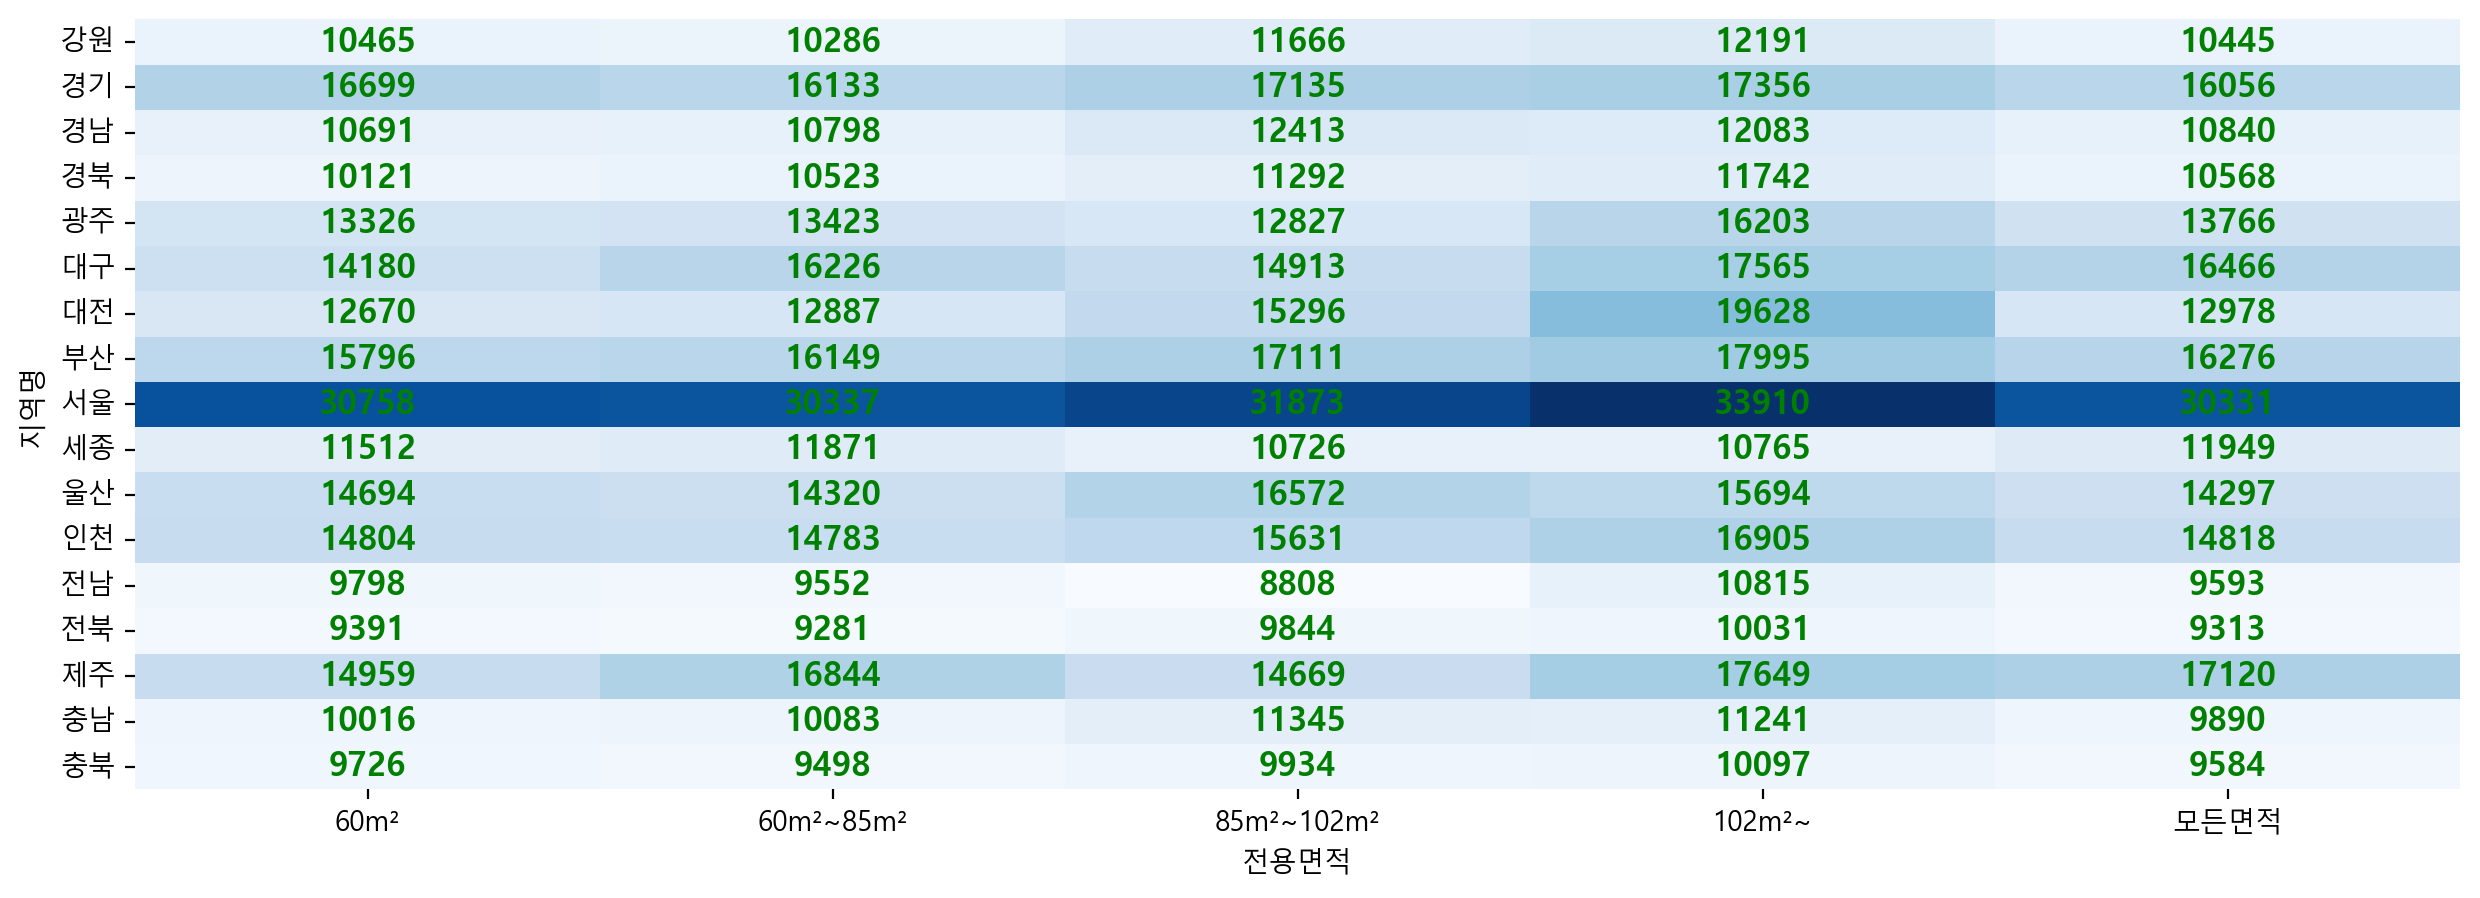

In [107]:
plt.figure(figsize=(15,5))
sns.heatmap(r, annot=True, fmt='.0f', cmap='Blues', annot_kws={'color':'green', 'size':12, 'weight':'bold'},cbar=False)
plt.show()

## (5) 연도, 지역별 평당분양가격(평균)

In [150]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     10880 non-null  object 
 1   전용면적    10880 non-null  object 
 2   연도      10880 non-null  int64  
 3   월       10880 non-null  int64  
 4   평당분양가격  9907 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 425.1+ KB


In [166]:
r = df_last.pivot_table(index='연도', columns='지역명', values='평당분양가격')
r.sample(5).sort_index()

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2016,7162.903846,11684.970,8496.730000,7753.405000,9190.683333,10282.030000,8910.733333,10743.535,21753.435,8857.805000,9582.574138,11099.055,6936.600000,6906.625000,9567.480000,7958.225000,7133.335000
2020,10302.423214,15106.080,10919.272222,9997.693750,13406.485714,15314.200000,11238.844737,13353.010,29781.015,11628.100000,12837.600000,14982.990,9562.398214,8559.430000,14192.876923,9139.380000,8358.956897
2021,10291.325000,14567.080,11302.335000,11227.150000,13709.850000,15586.285000,11994.216667,14317.655,29380.450,12578.060000,14191.953061,15774.330,9980.760000,9047.928814,22302.342857,9860.741379,8822.385000
2024,15443.285000,22247.445,13656.031915,14226.934615,18516.360000,22192.300000,19692.530000,22431.145,44543.620,17902.500000,18307.740000,18615.575,13425.156250,12365.630357,25225.658333,12769.634483,13148.281034
2026,17124.096000,22455.180,15143.040000,14020.462500,21460.594737,31924.394118,18961.800000,28490.484,50800.728,18236.964706,19058.073913,26430.228,13109.336842,13345.026316,14658.988235,14843.400000,14814.492000


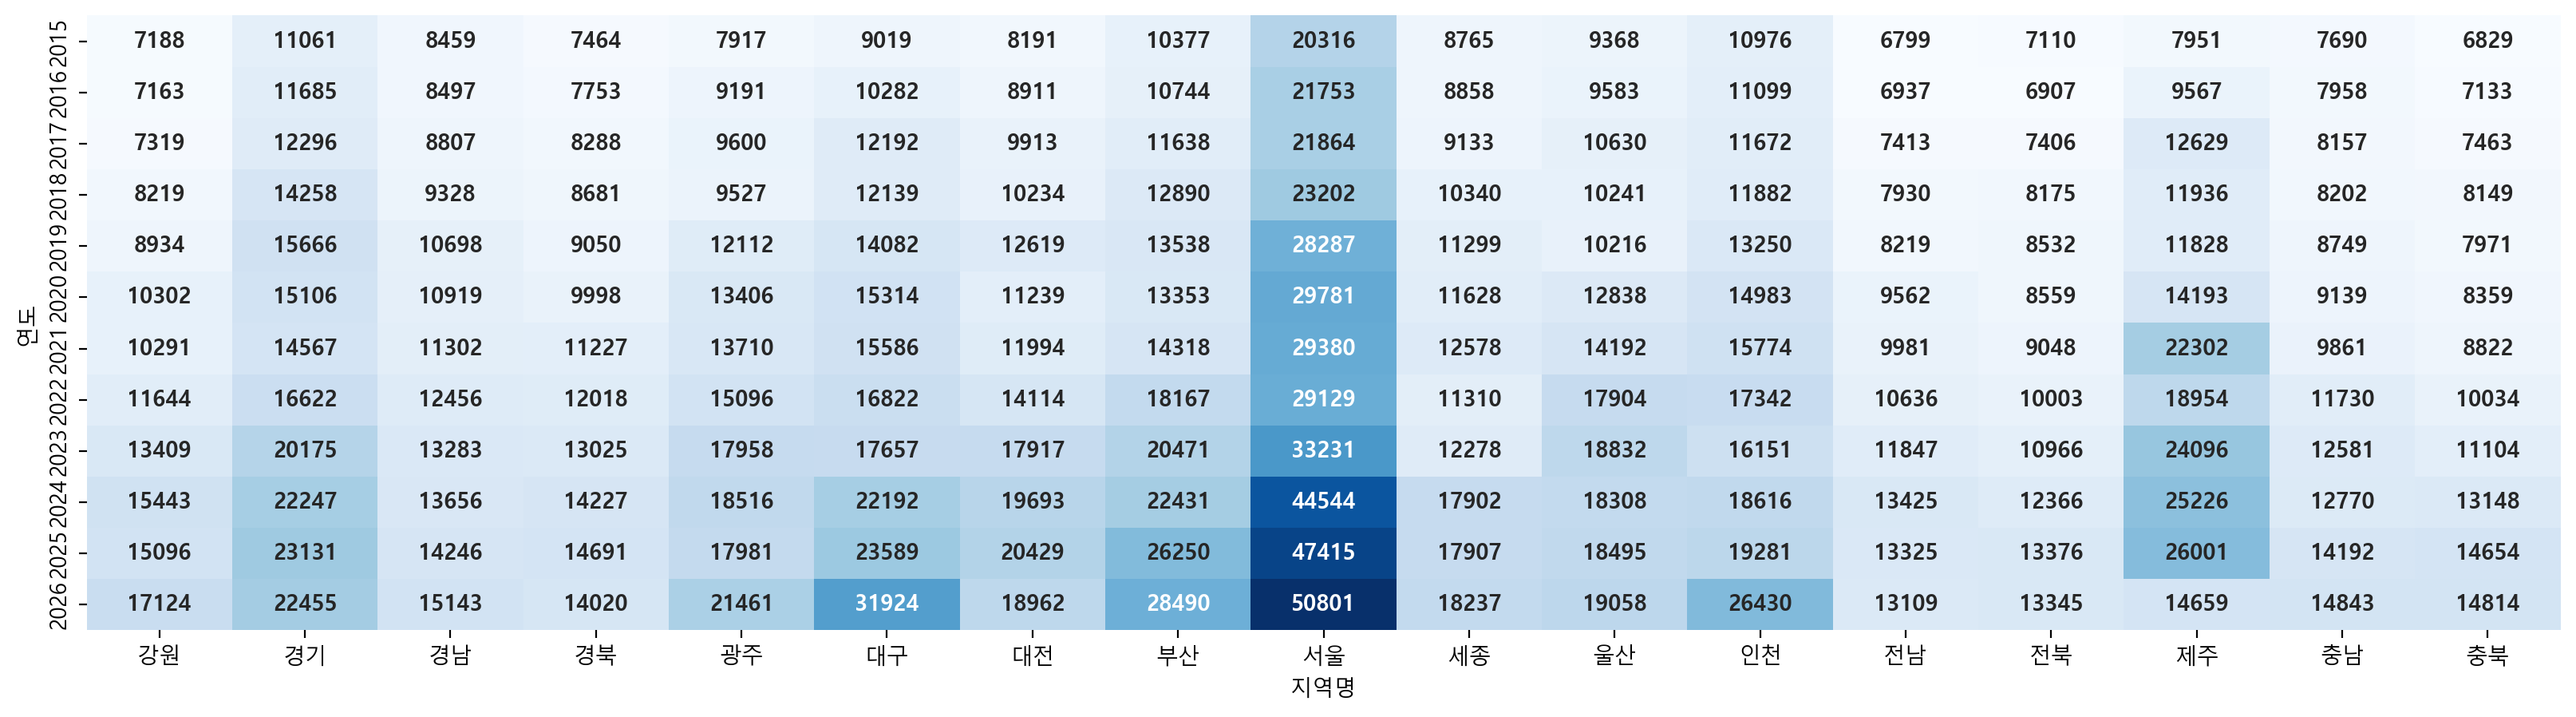

In [169]:
plt.figure(figsize=(20,5))
sns.heatmap(r, annot=True, fmt='.0f', cmap='Blues', cbar=False, annot_kws={'weight' : 'bold'})
plt.show()

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

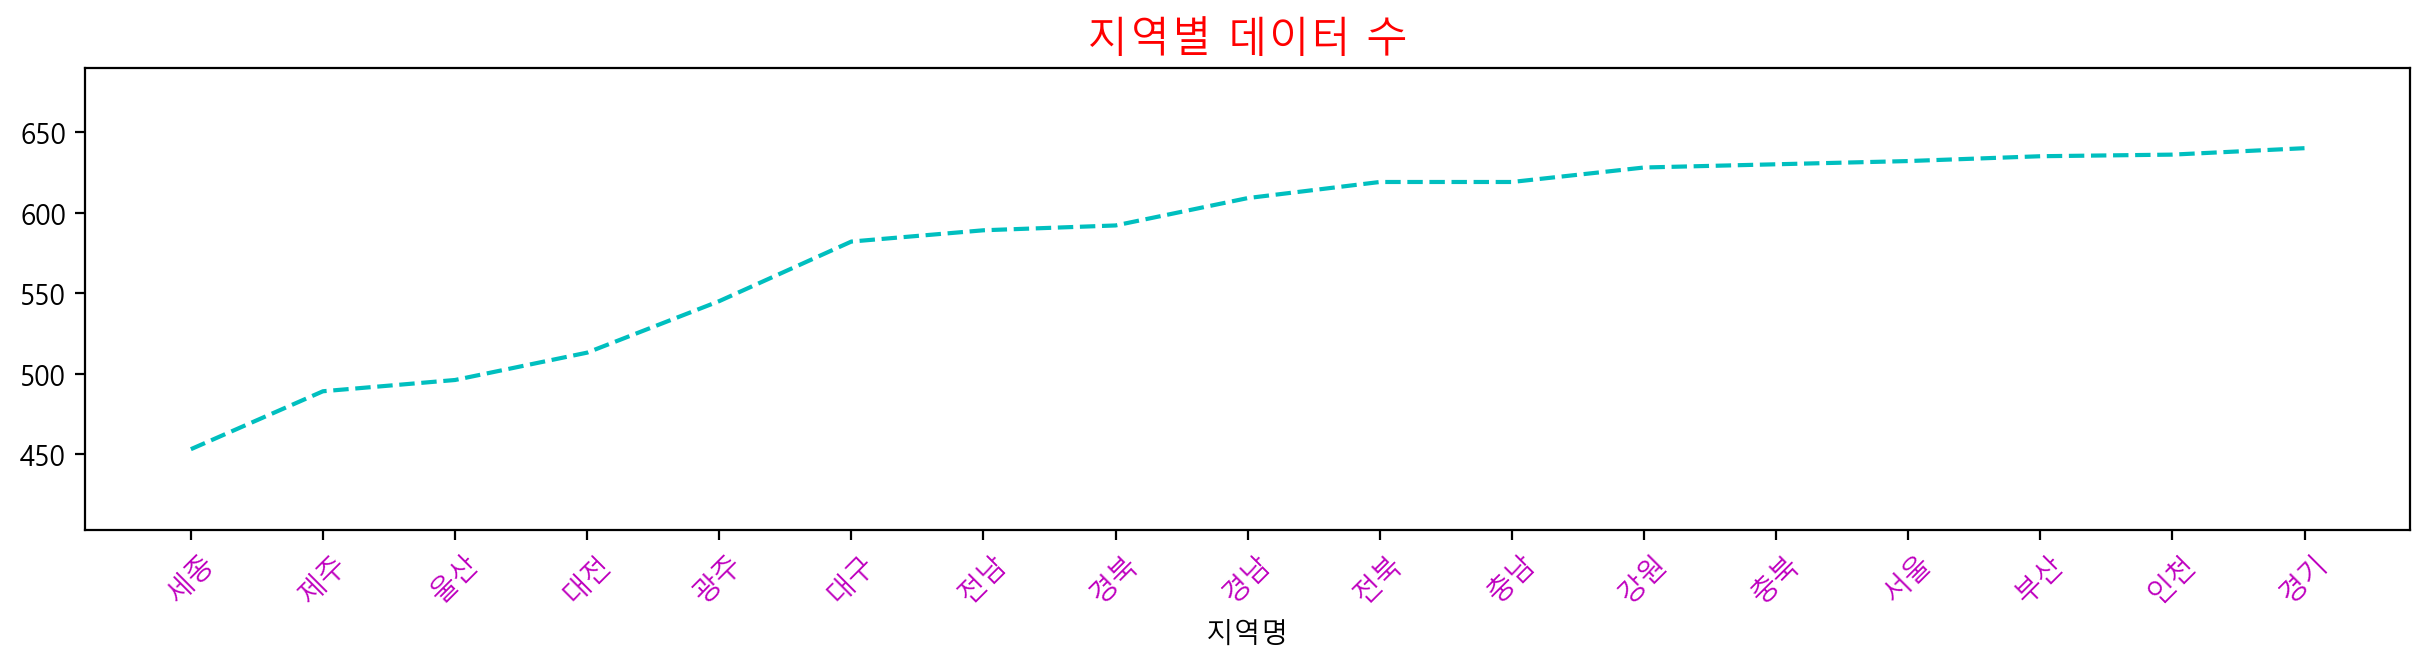

In [192]:
plt.figure(figsize=(15,3))
plt.rcParams['figure.figsize'] = (15, 3)
result = df_last.groupby('지역명')['평당분양가격'].count().sort_values()
# result.plot(kind='line') # plot: pandas의 그래프 함수 #kind='line' 선 그래프
# result.plot.line()
ax = result.plot(kind='line', color='c', linestyle='--', rot=45) 
            # ylim=[result.min()-50, result.max()+50], title='지역별 데이터 수'
plt.title('지역별 데이터 수', color='#FF0000', size=15)
plt.ylim([result.min()-50, result.max()+50]) # 축범위
plt.xticks(range(len(result))) # 축눈금
ax.set_xticklabels(result.index, color='m') # 눈금라벨
plt.show()

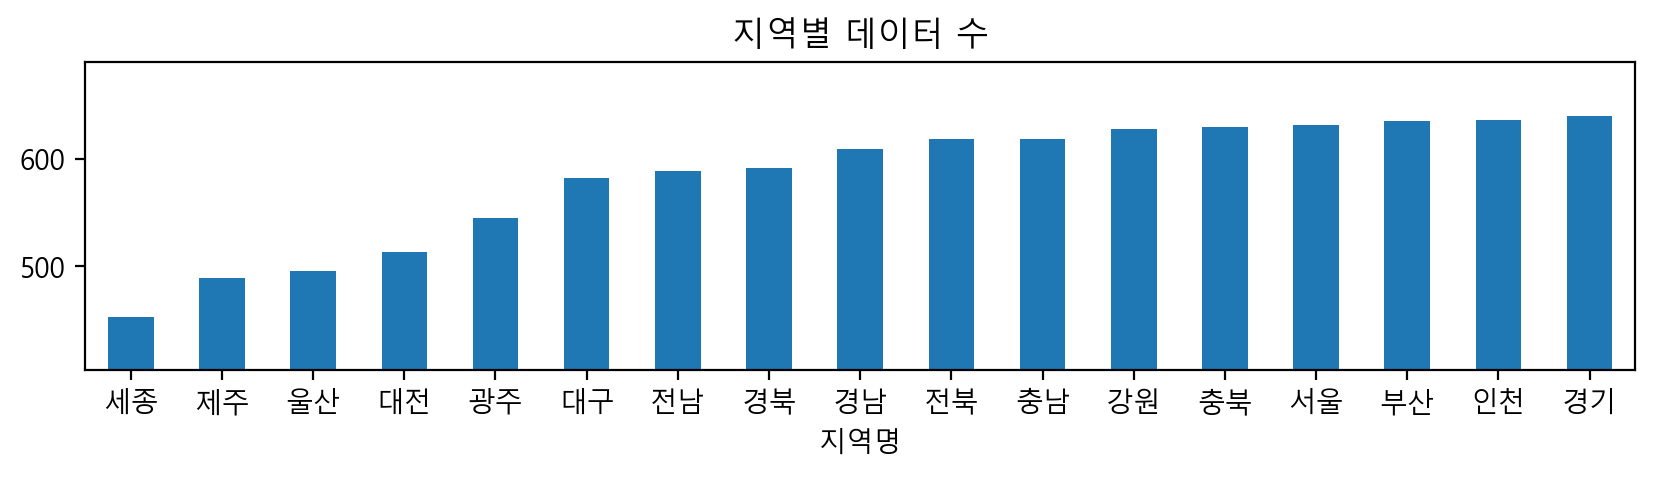

In [197]:
result.plot.bar(rot=0, figsize=(10, 2), title='지역별 데이터 수', ylim=[result.min()-50, result.max()+50])
# result.plot(kind='bar')
plt.show()

## (2) 지역별 평당분양가격 (line, bar)

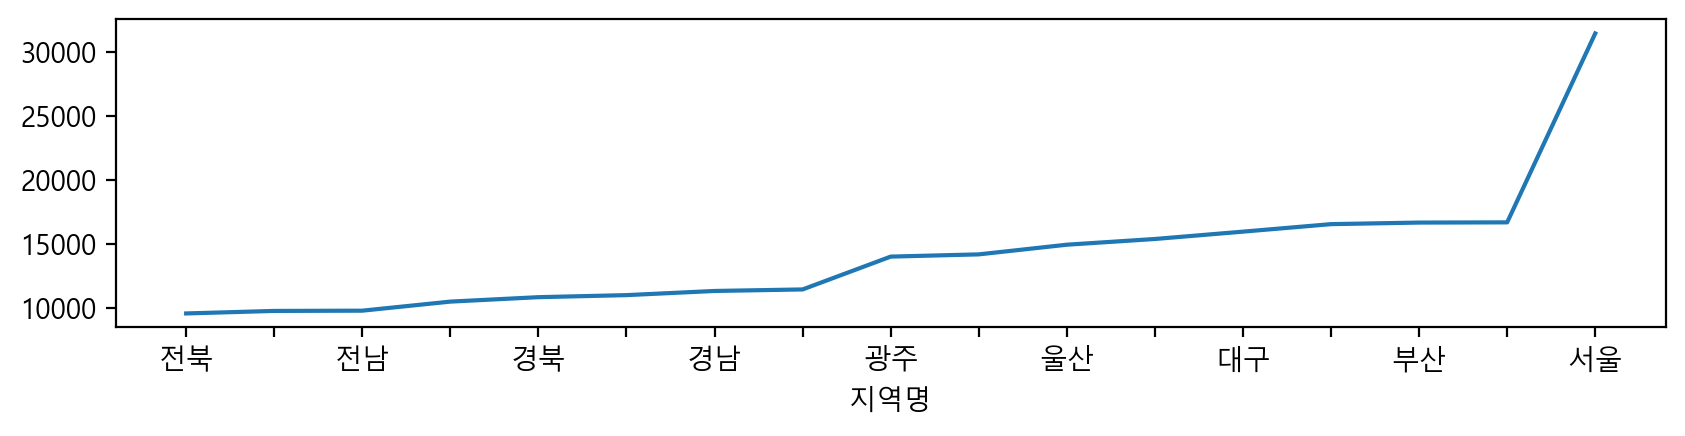

In [203]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='line')
plt.xticks(range(len(result))) # 축눈금
ax.set_xticklabels(result.index, color='m') # 눈금라벨
plt.show()

## (3) 전용면적별 평당분양가격(barplot)

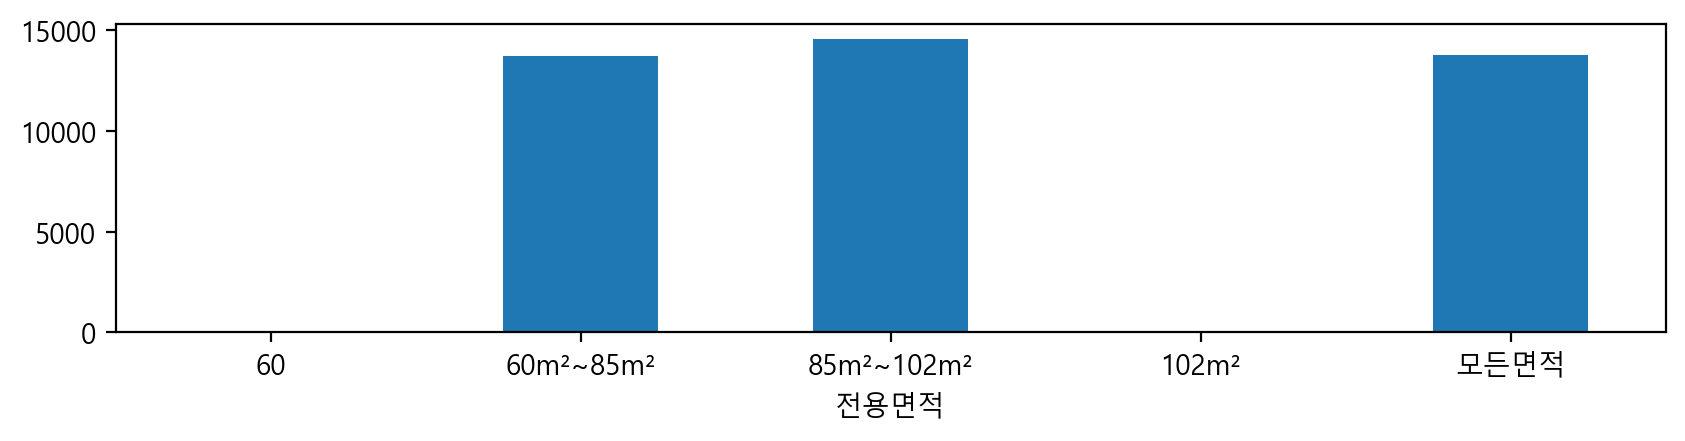

In [218]:
order = ['60','60m²~85m²', '85m²~102m²', '102m²','모든면적']
result = df_last.groupby('전용면적')['평당분양가격'].mean().reindex(order).plot(kind='bar', rot=0)
df_last.groupby('전용면적')['평당분양가격'].mean().reindex(order).plot(kind='bar', rot=0)
plt.show()

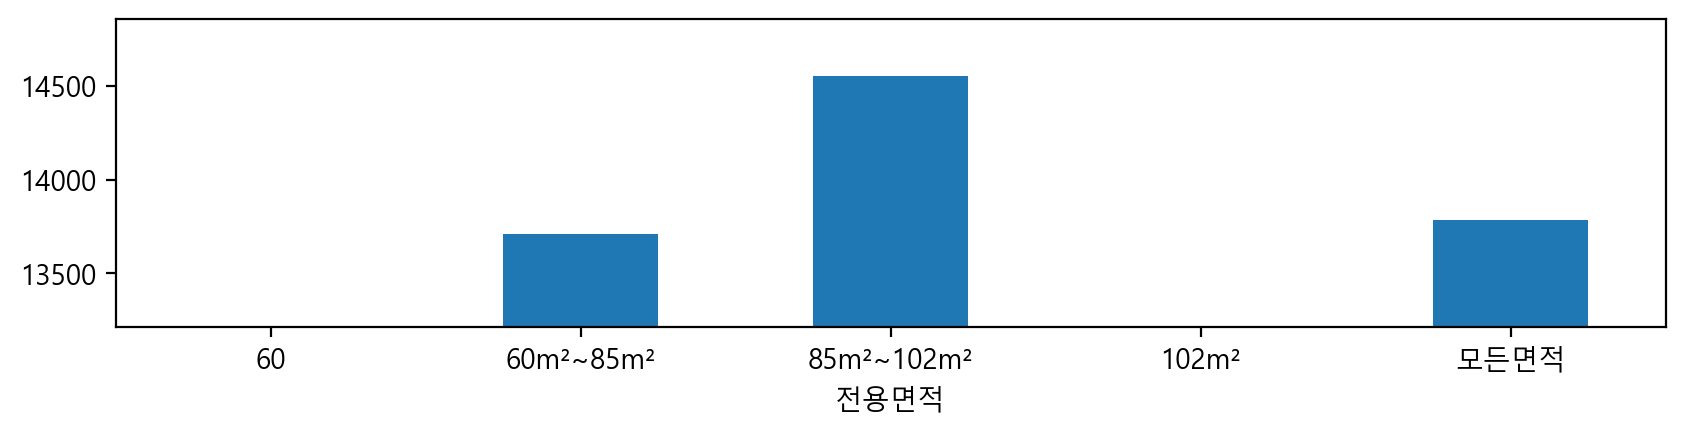

In [221]:
order = ['60','60m²~85m²', '85m²~102m²', '102m²','모든면적']
result = df_last.groupby('전용면적')['평당분양가격'].mean().reindex(order)
result.plot(kind='bar', rot=0, ylim=[result.min()-500, result.max()+300])
plt.show()

In [235]:
result

연도
2015     9202.735802
2016     9683.025000
2017    10372.928923
2018    10978.938411
2019    12188.293092
2020    13039.422449
2021    13636.022540
2022    14942.504494
2023    16890.920657
2024    19193.255439
2025    20058.105823
2026    21111.425266
Name: 평당분양가격, dtype: float64

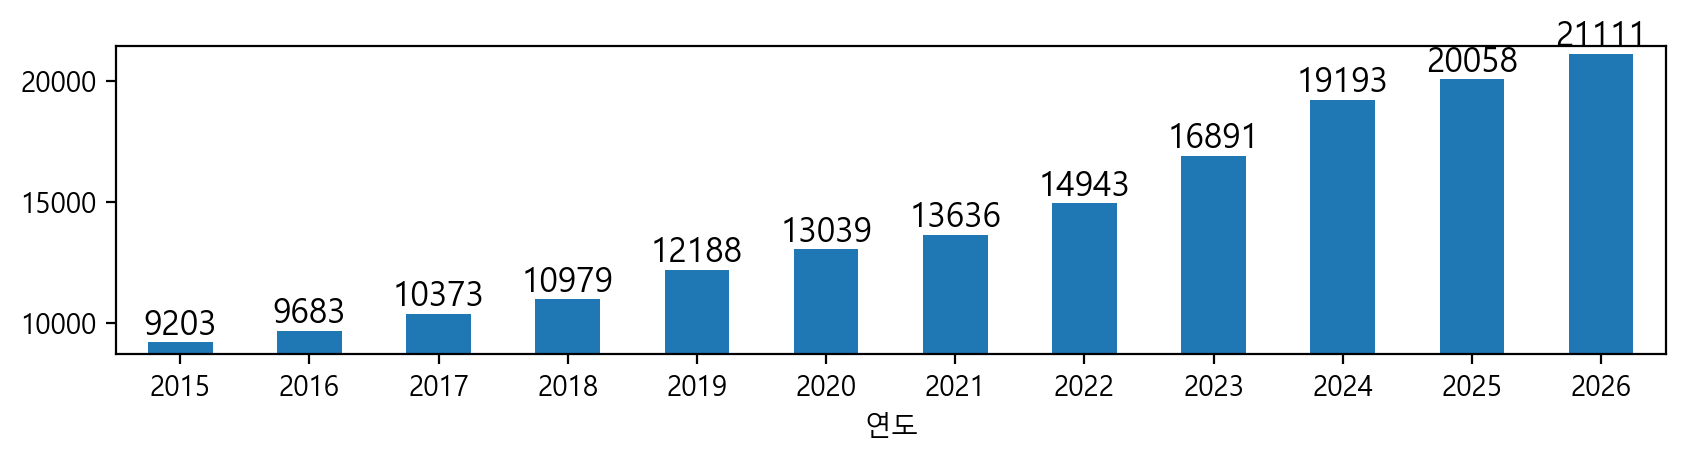

In [236]:
# result.plot(kind='bar', rot=0, ylim=[result.min()-500, result.max()+300])
# for i, val in enumerate(result) :
#     # plt.text(i-0.1, val+70, round(val), fontsize=12)
#     # va:수직정렬, ha:수평정렬
#     plt.text(i, val, round(val), fontsize=12, va='bottom', ha='center')
# plt.show()
import pandas as pd

result.plot(kind='bar', rot=0,
            ylim=[result.min()-500, result.max()+300])

for i, val in enumerate(result):
    if pd.notna(val):   # NaN이 아닐 때만 실행
        plt.text(i, val, round(val), fontsize=12,
                 va='bottom', ha='center')

plt.show()

## (4) 연도별 평균 평당분양가격(line)

In [237]:
result = df_last.groupby('연도')['평당분양가격'].mean()
for year, val in result.items():
    print(year, val)

2015 9202.735802469135
2016 9683.025
2017 10372.928923076923
2018 10978.938411316649
2019 12188.293092105265
2020 13039.42244897959
2021 13636.02253968254
2022 14942.504494382023
2023 16890.92065677966
2024 19193.25543859649
2025 20058.10582306831
2026 21111.42526595745


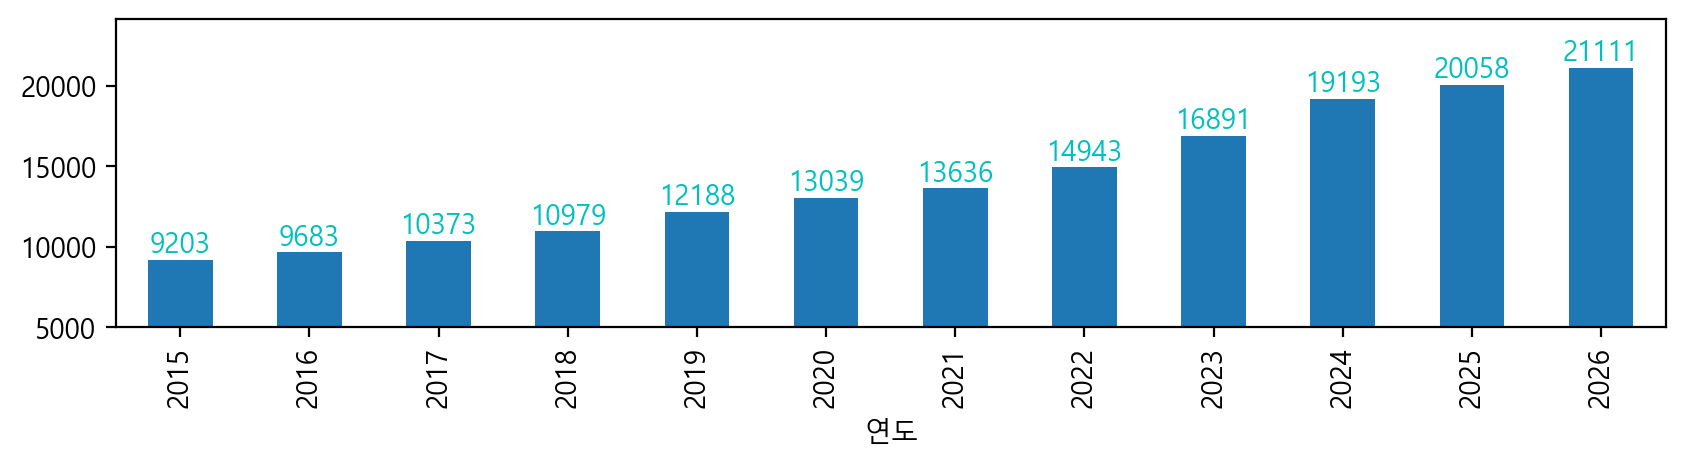

In [241]:
result.plot(kind='bar', ylim=[5000, result.max()+3000])
for i, val in enumerate(result) :
    plt.text(i, val, round(val), va='bottom', ha='center', color='c')

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [244]:
sns.set(style='white', rc={'figure.figsize':(12,3)})
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

<function matplotlib.pyplot.show(close=None, block=None)>

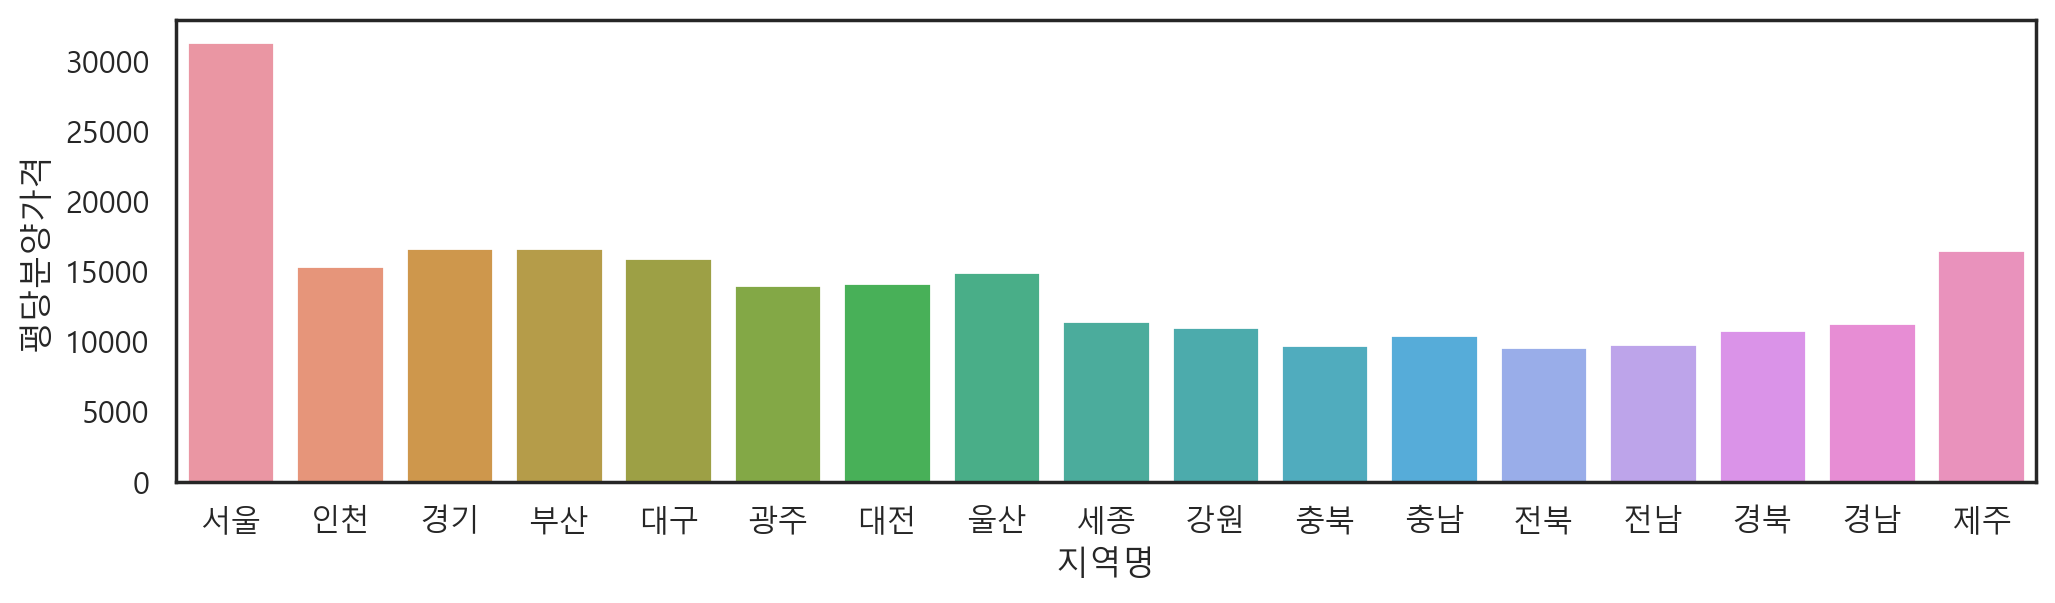

In [245]:
sns.barplot(data=df_last, x='지역명', y='평당분양가격', errorbar=None)
plt.show()

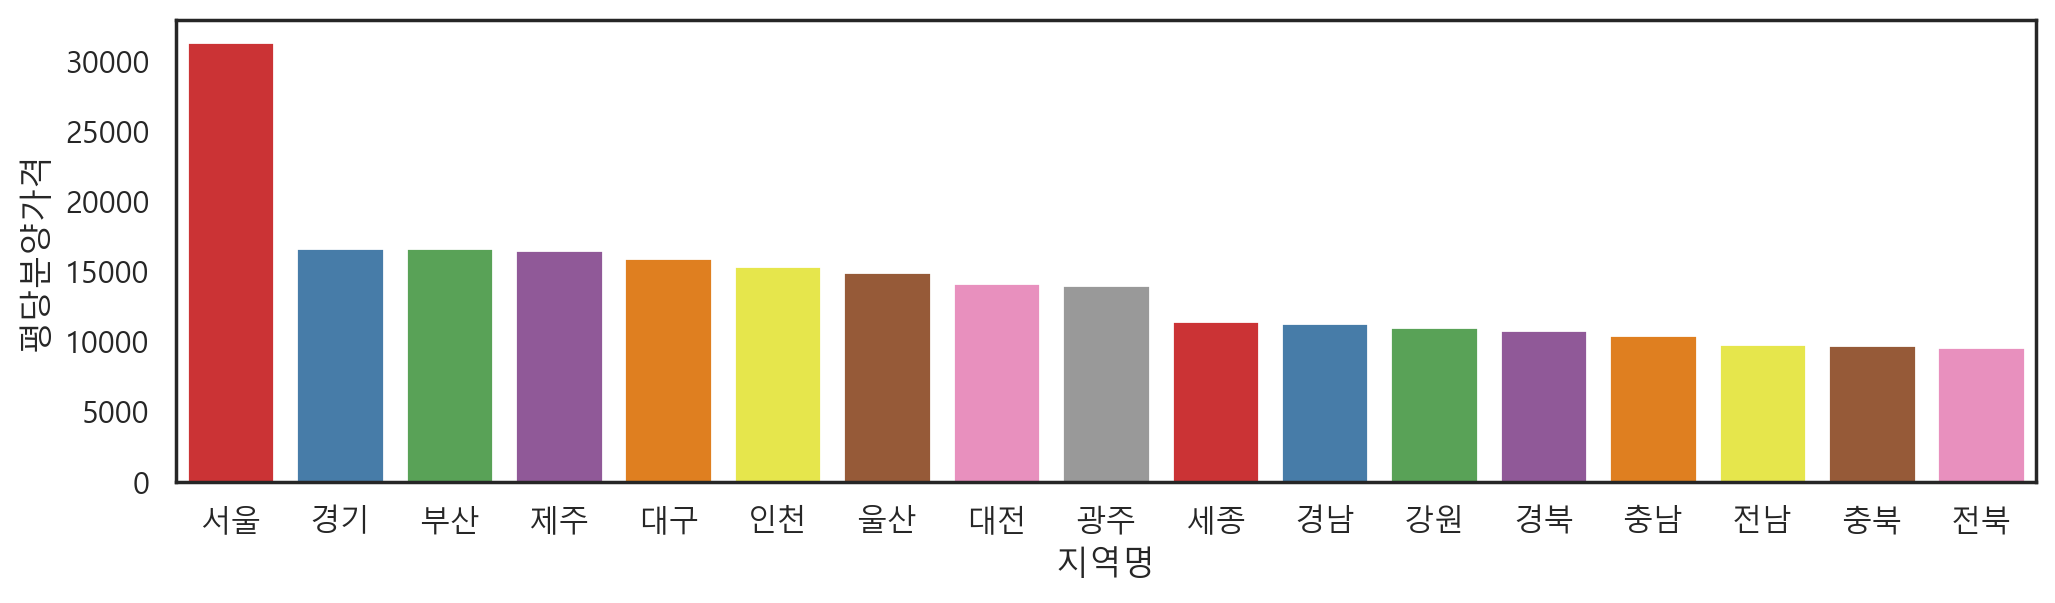

In [247]:
result = df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last, x='지역명', y='평당분양가격', errorbar=None, order=result.index, palette='Set1')
plt.show()

In [250]:
for i , val in enumerate(result) :
    print(i, val)

0 31416.731012658227
1 16675.7765625
2 16658.924881889765
3 16536.99509202454
4 15951.406185567012
5 15378.612264150945
6 14932.213911290322
7 14177.752046783626
8 14003.631743119266
9 11442.134437086093
10 11322.646798029557
11 10998.011942675159
12 10838.521114864865
13 10492.272697899838
14 9784.729711375212
15 9765.255238095238
16 9568.656542810986


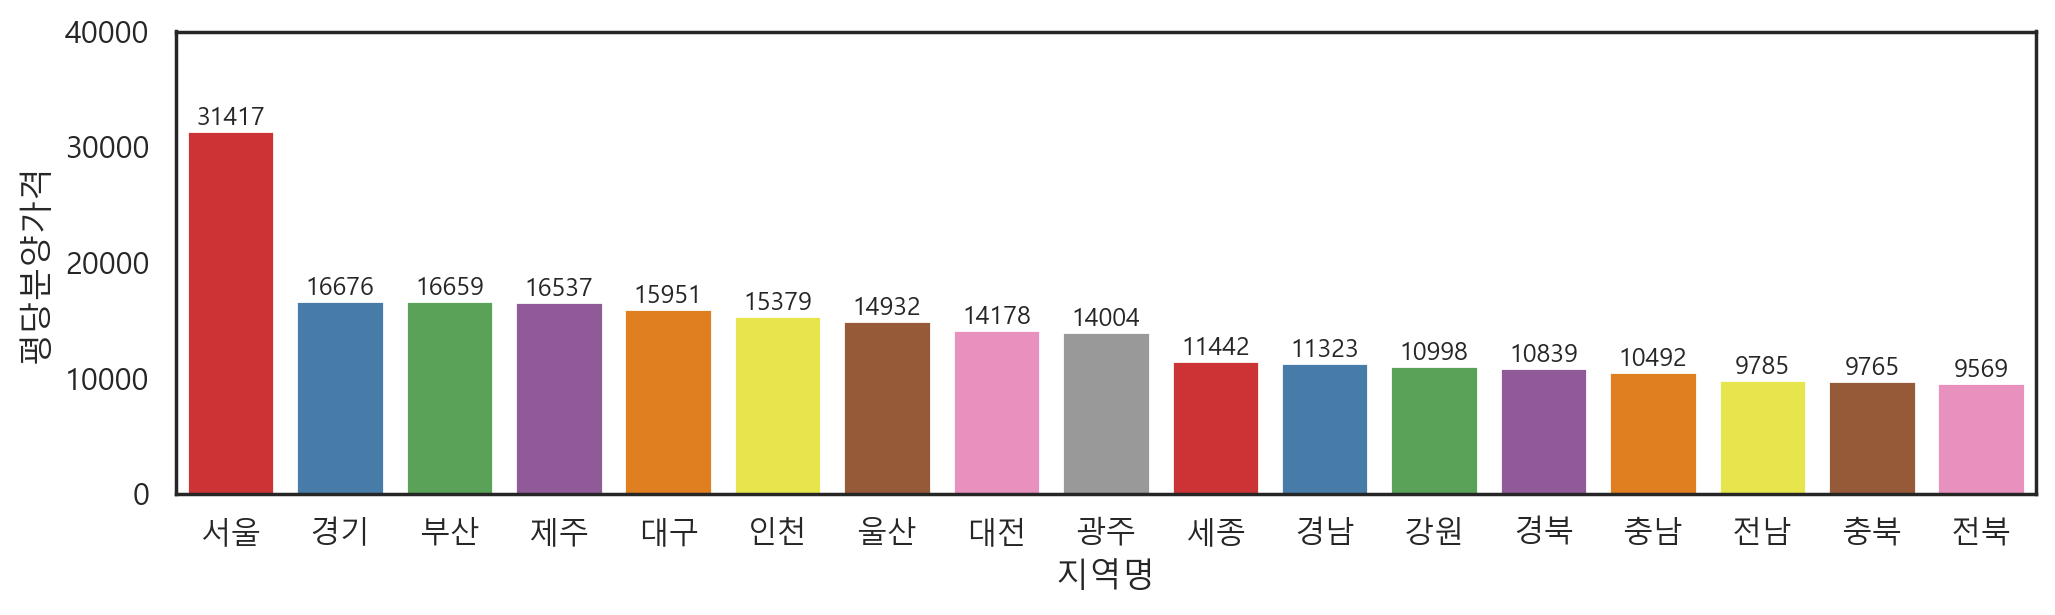

In [254]:
result = df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last, x='지역명', y='평당분양가격', errorbar=None, order=result.index, palette='Set1')
plt.ylim([0, 40000])
for i, v in enumerate(result) :
    plt.text(i, v, round(v), va='bottom', ha='center', fontsize=9)
plt.show()

## (2) 연도별 평당분양가격

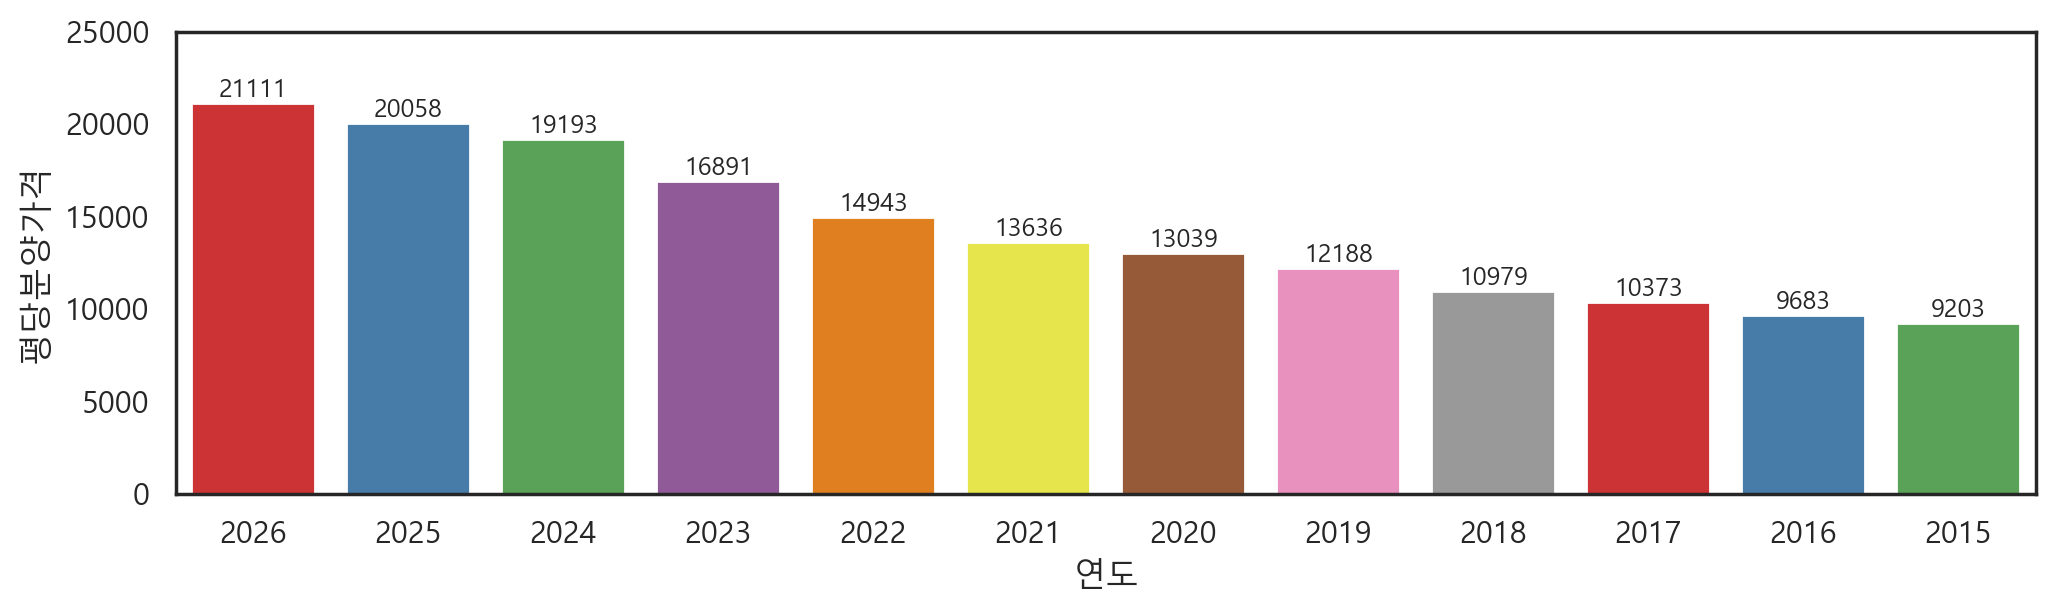

In [258]:
result = df_last.groupby('연도')['평당분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last, x='연도', y='평당분양가격', errorbar=None, order=result.index, palette='Set1')
plt.ylim([0, 25000])
for i, v in enumerate(result) :
    plt.text(i, v, round(v), va='bottom', ha='center', fontsize=9)
plt.show()

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxexplot, regplot, swarmplot

<function matplotlib.pyplot.show(close=None, block=None)>

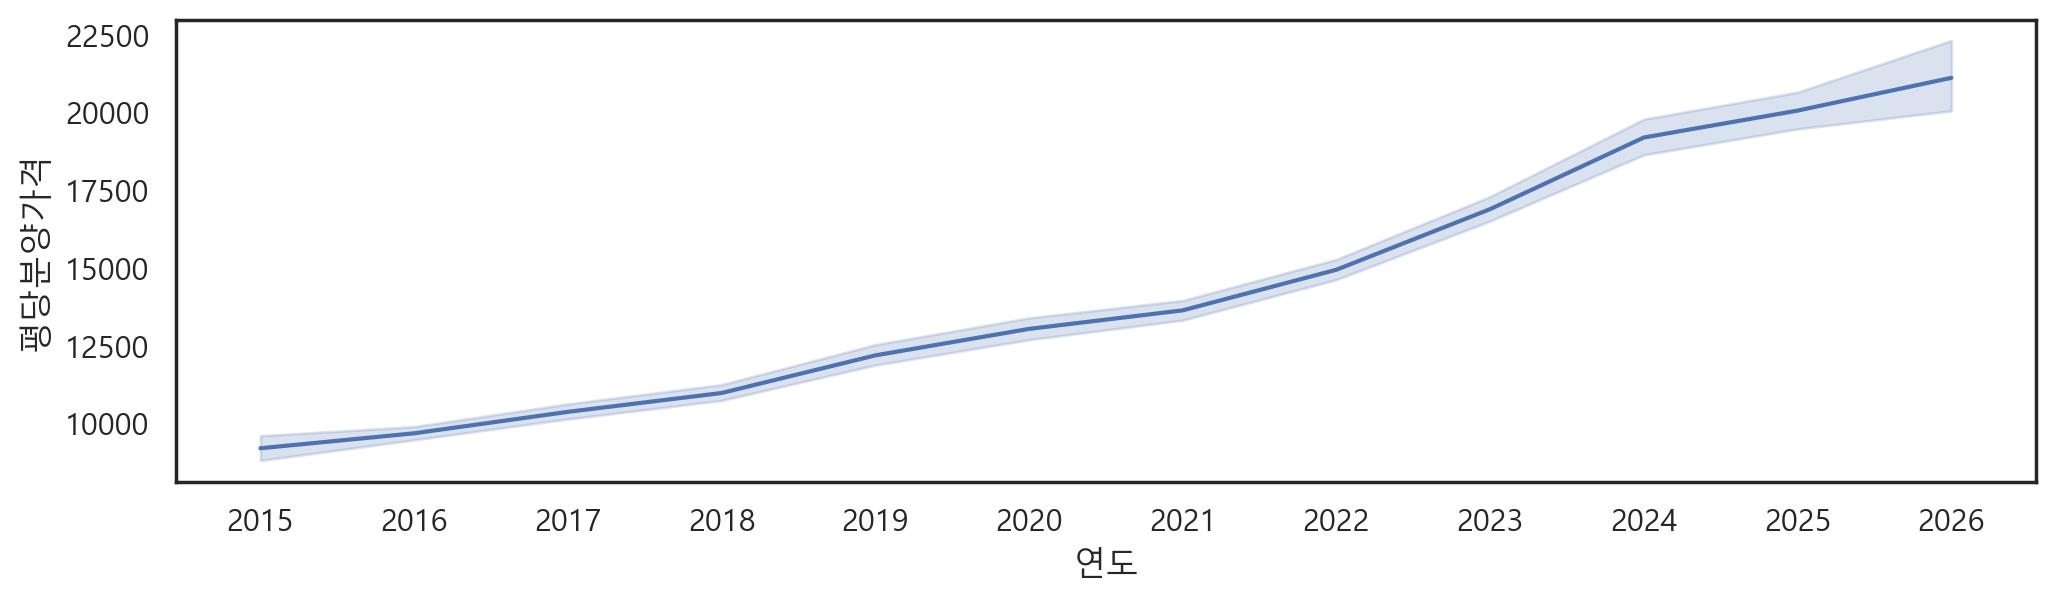

In [259]:
# 년도별 평균 분양가격 추이
sns.lineplot(data=df_last, x='연도', y='평당분양가격')
plt.xticks(range(2015,2027))
plt.show

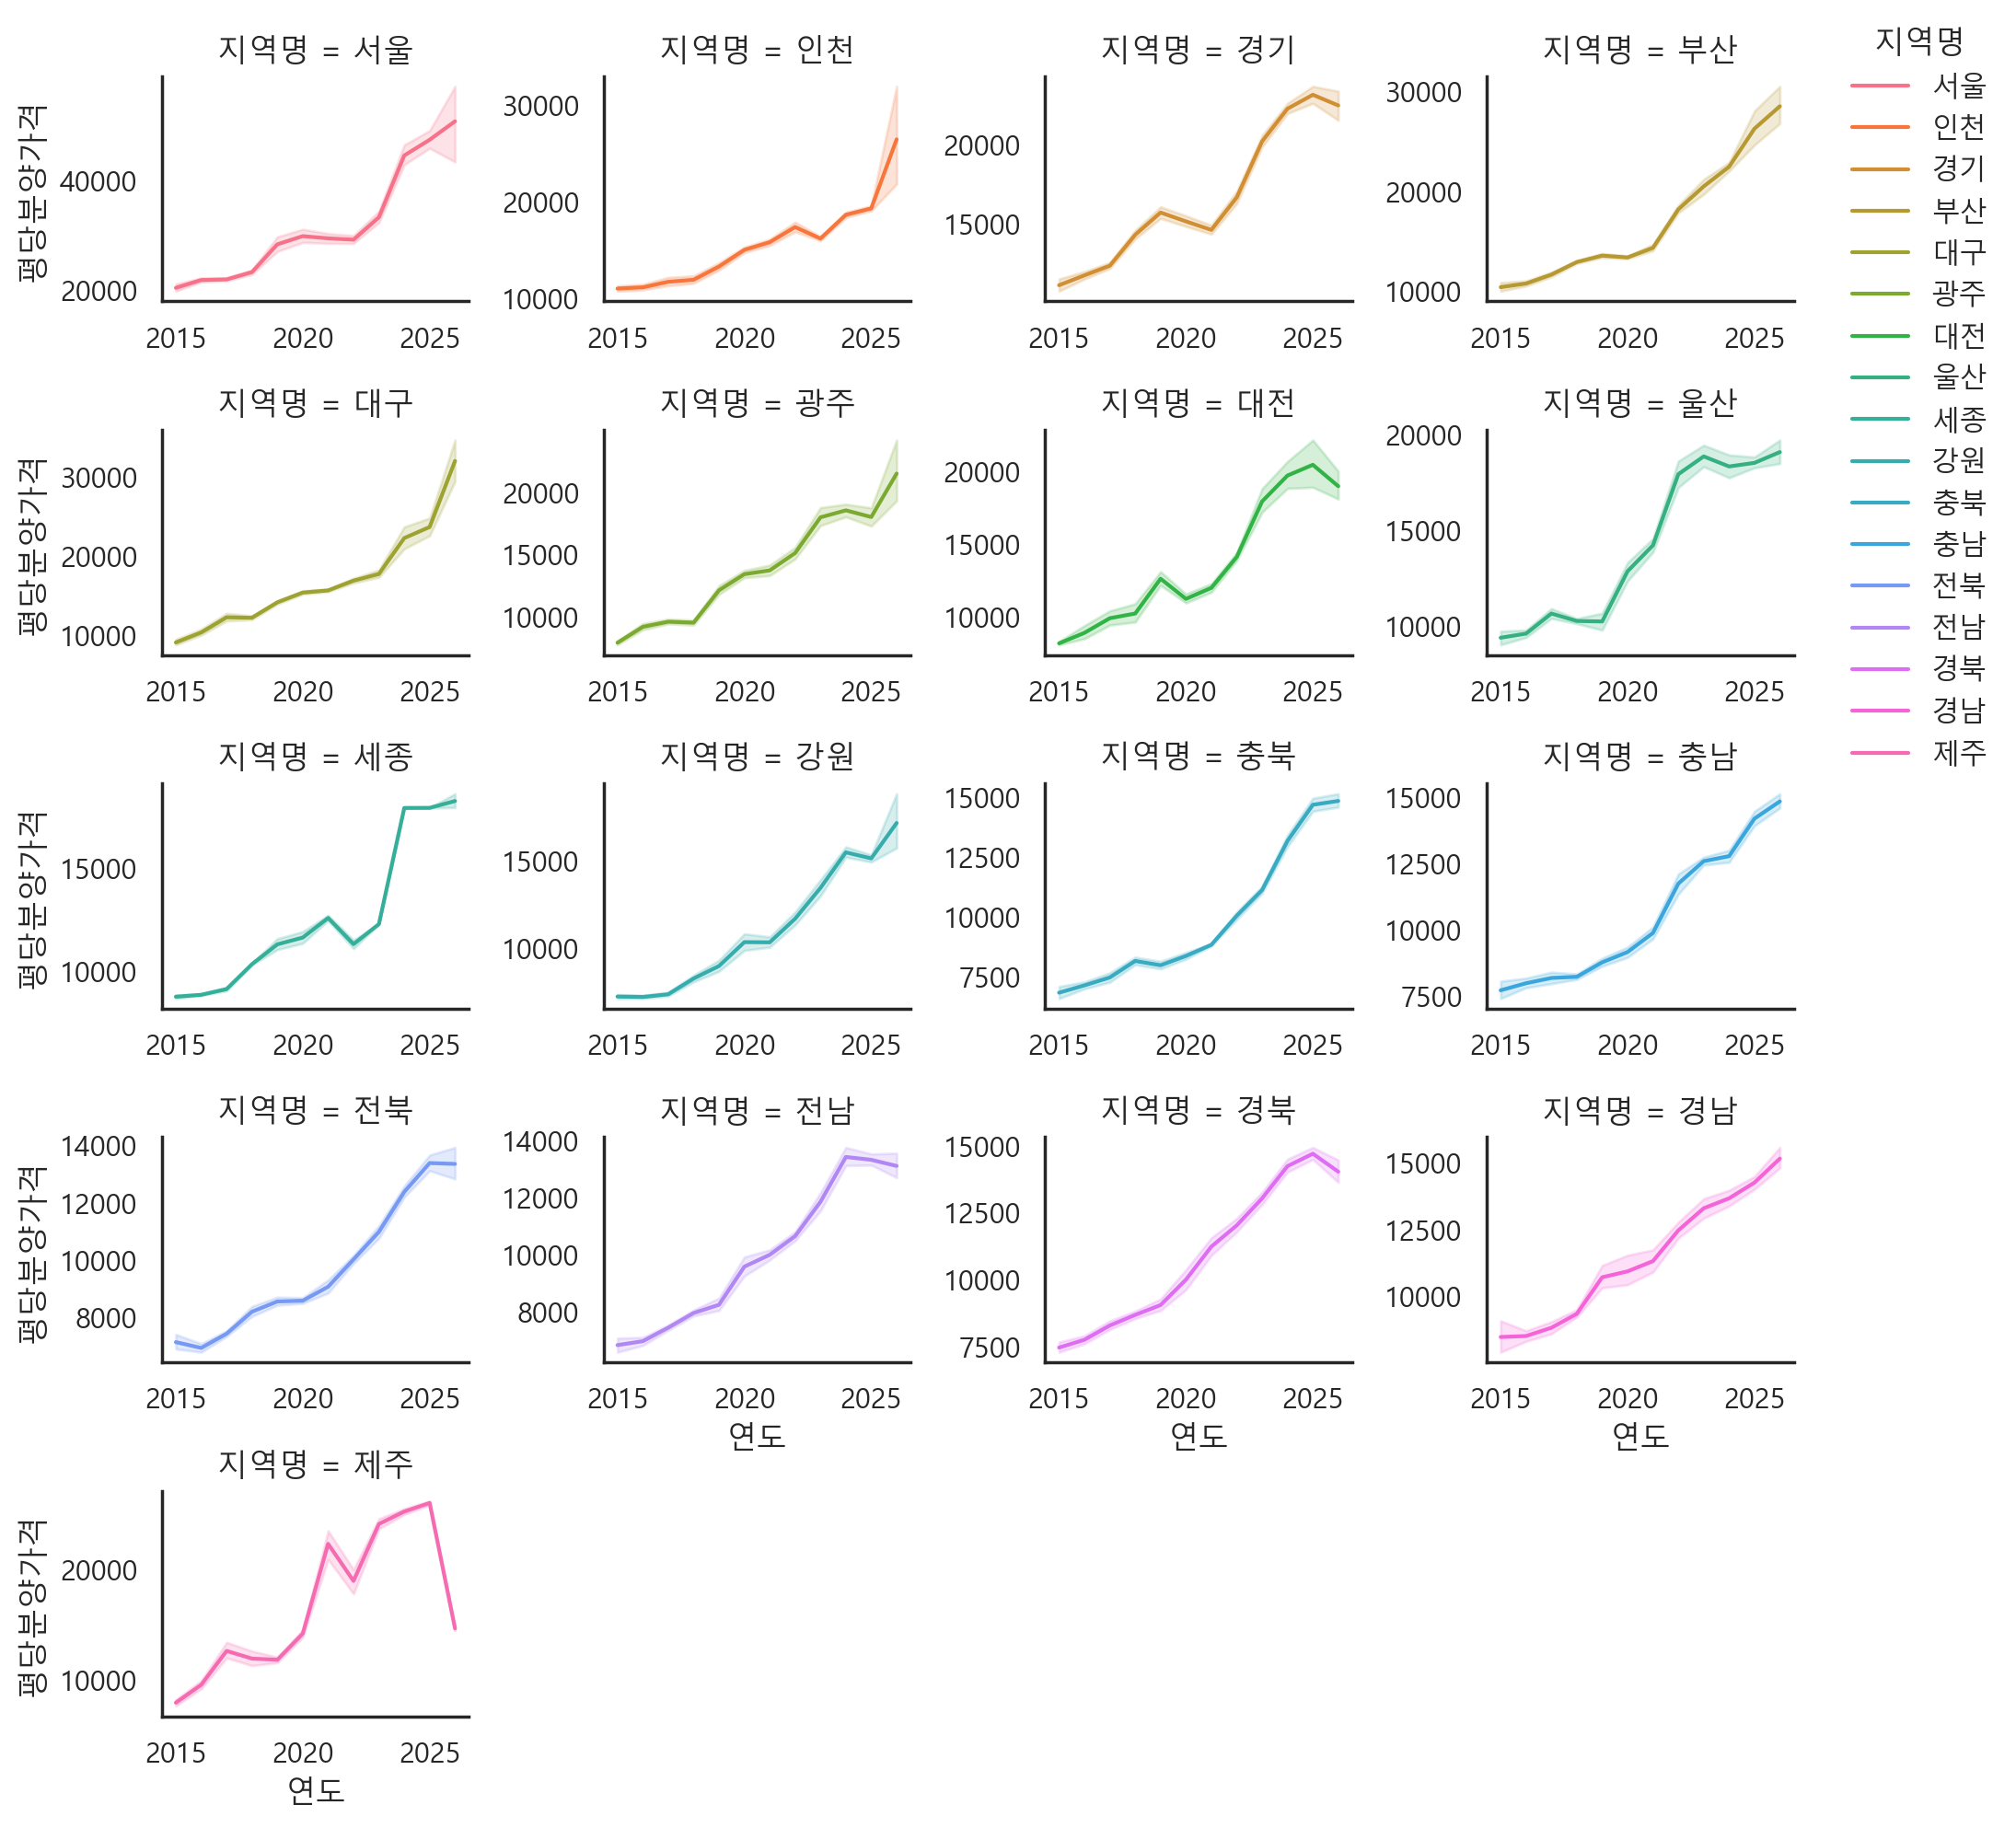

In [269]:
# 년도별, 지역별 평당분양가격을 지역별로 서브플롯(relplot)
g = sns.relplot(data=df_last, x='연도', y='평당분양가격', kind='line', hue='지역명', col='지역명', col_wrap=4, facet_kws={'sharex':False, 'sharey':False})
g.fig.set_size_inches(10,10)
plt.tight_layout()
sns.move_legend(g, "upper left", bbox_to_anchor=(1,1))
plt.show()

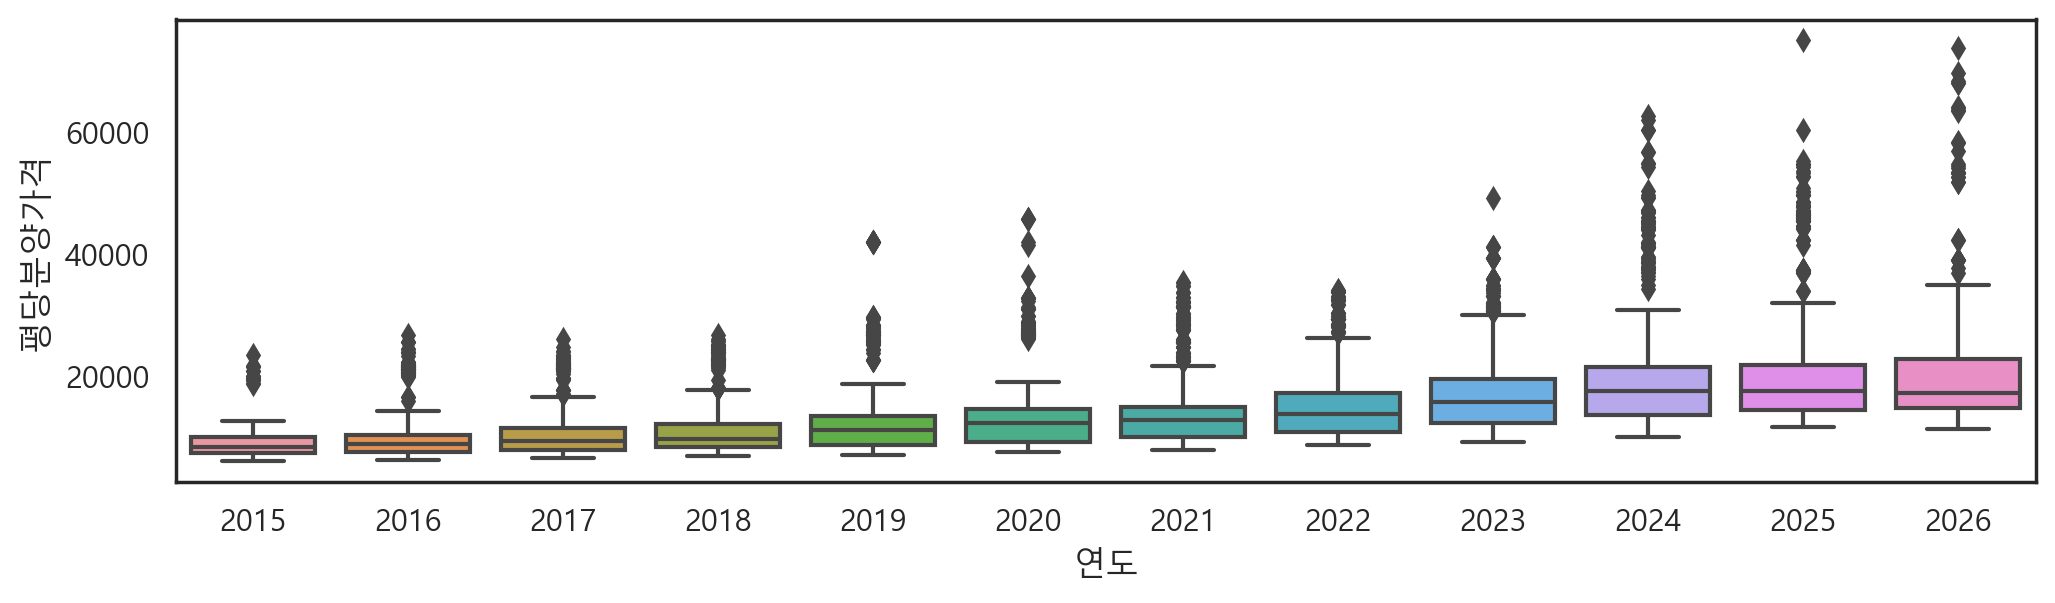

In [273]:
# 연도별 평당분양가격의 boxplot, violinplot, boxexplots
sns.boxplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

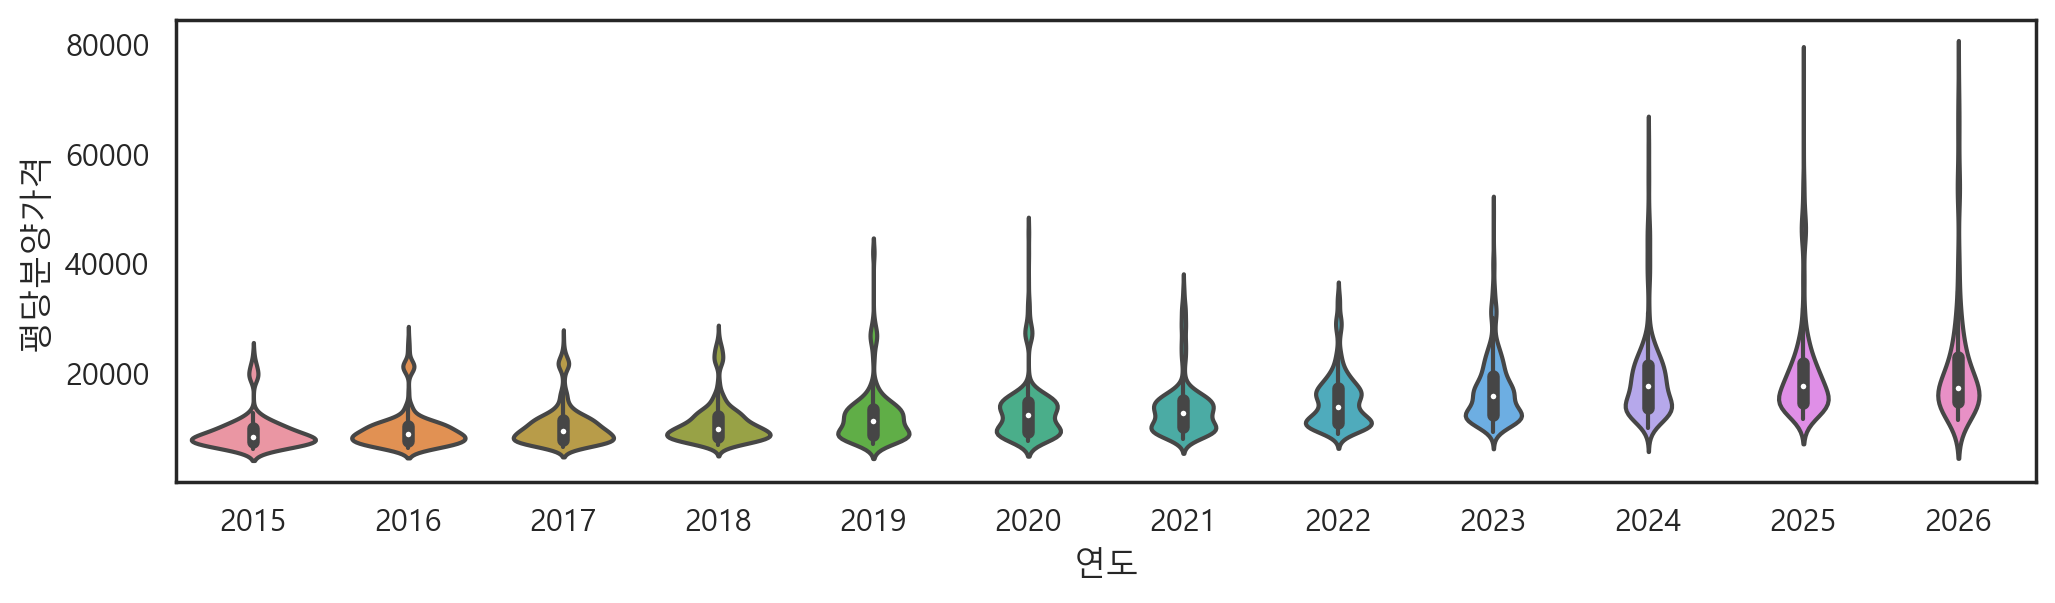

In [274]:
# 연도별 평당분양가격의 boxplot, violinplot, boxexplots
sns.violinplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

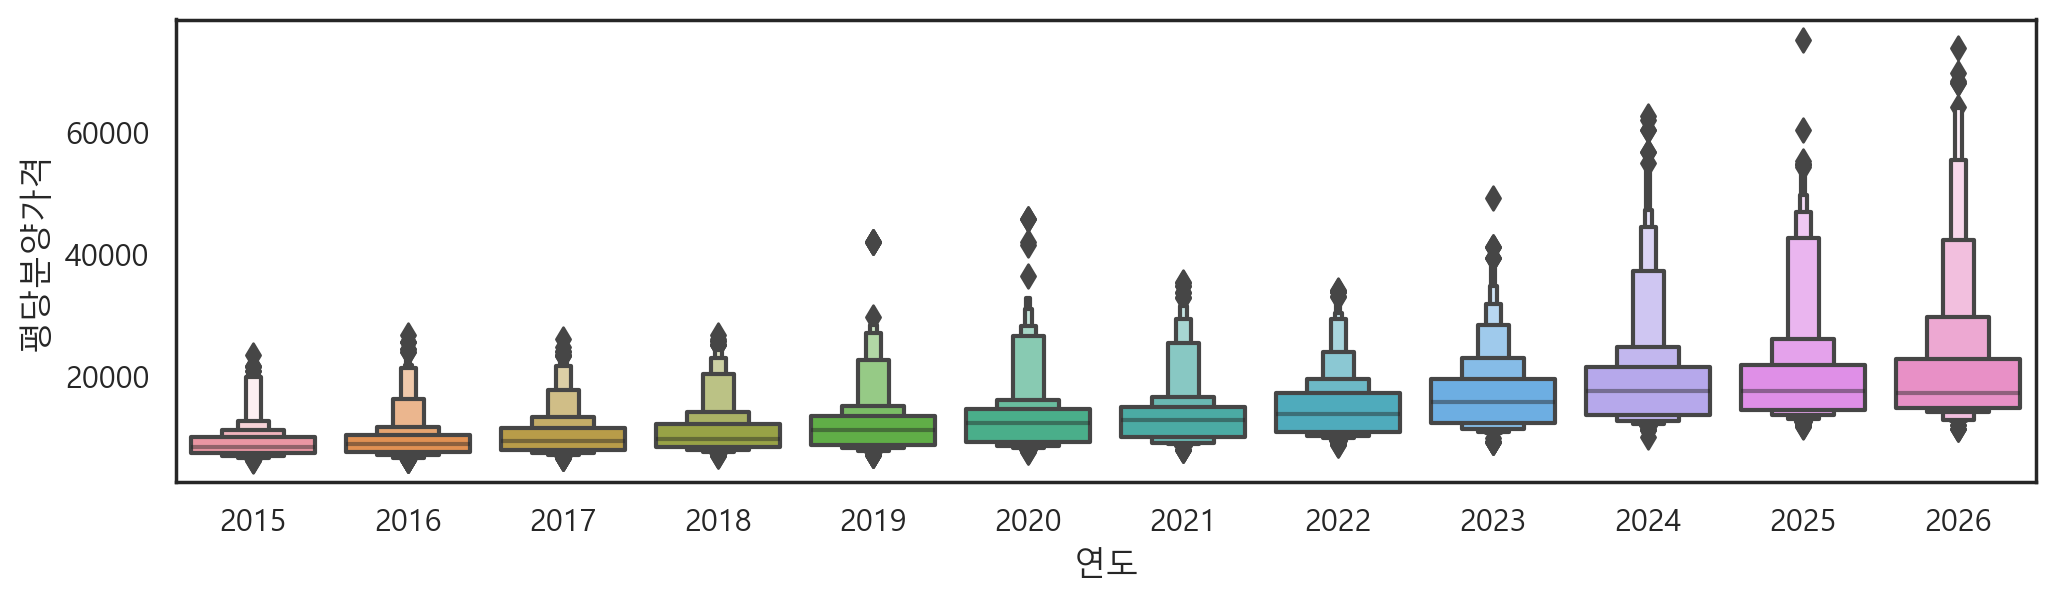

In [278]:
# 연도별 평당분양가격의 boxplot, violinplot, boxenplots
sns.boxenplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

In [ ]:
# 연도별 평당분양가격 산점도
# sns.swarmplot(data=df_last, x='연도', y='평당분양가격', size=3)
# plt.show()

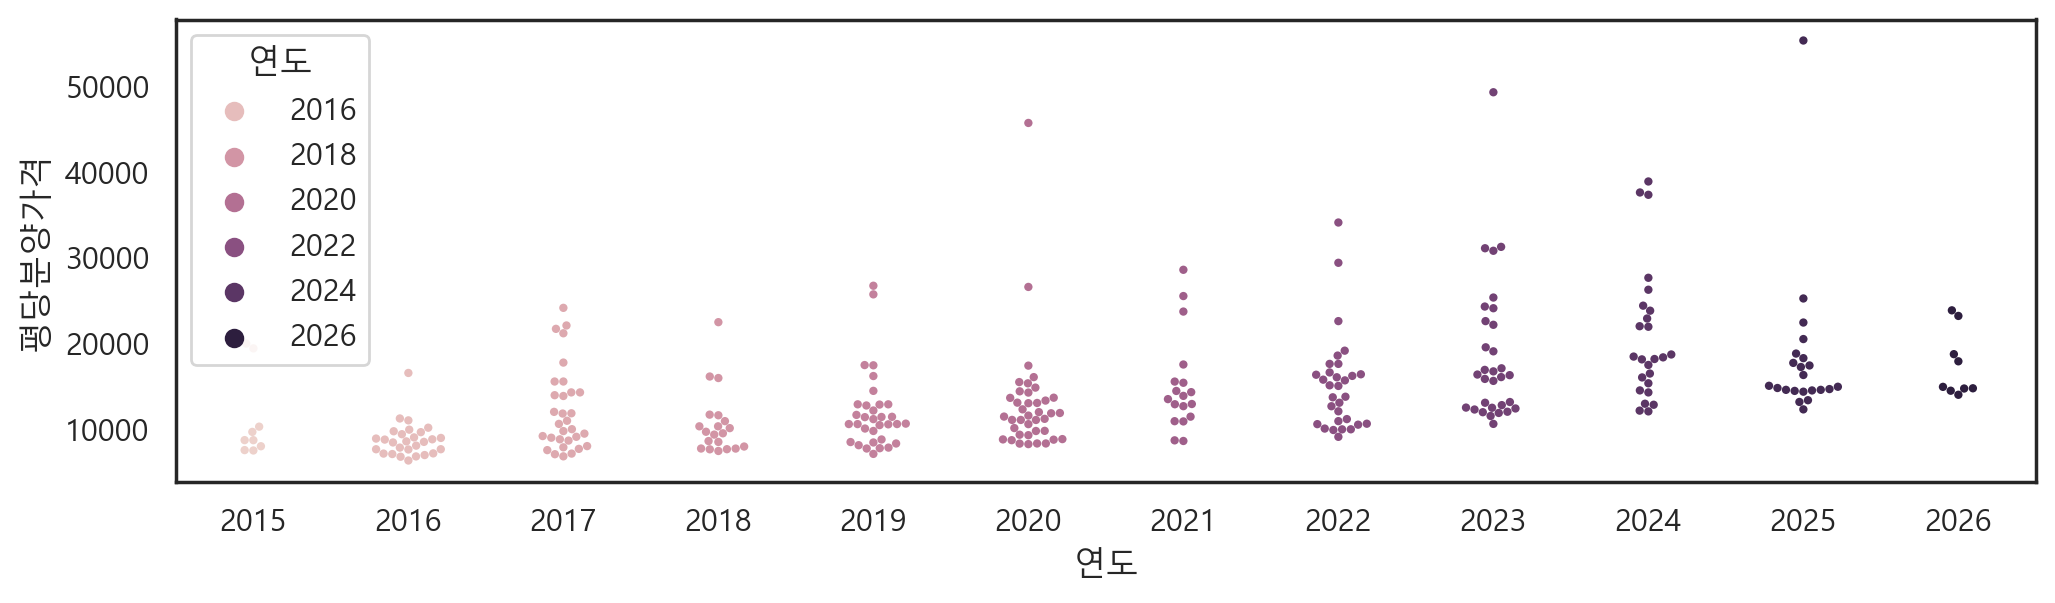

CPU times: total: 1.03 s
Wall time: 1.06 s


In [285]:
%%time
# df_last.sample(frac=0.05).sort_index() # fraction : 비율
sns.swarmplot(data=df_last.sample(frac=0.03), x='연도', y='평당분양가격', size=3, hue='연도')
plt.show()

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat
- new_first :df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)

In [339]:
df_first = pd.read_csv('C:/ai/downloads/sharedata/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581


In [340]:
new_first = df_first.melt(id_vars='지역', var_name='연도월', value_name='평당분양가격')
new_first.head(1)

,지역,연도월,평당분양가격
0,서울,2013년12월,18189


In [342]:
# map이나 apply를 이용해서 연도와 월 컬럼추가
new_first['연도'] = new_first['연도월'].apply(lambda x : int(x.split('년')[0]) )
new_first.head()

,지역,연도월,평당분양가격,연도
0,서울,2013년12월,18189,2013
1,부산,2013년12월,8111,2013
2,대구,2013년12월,8080,2013
3,인천,2013년12월,10204,2013
4,광주,2013년12월,6098,2013


In [343]:
new_first['연도월'].apply(lambda x : x.split('년')[1].replace('월', ''))
new_first['월'] = new_first['연도월'].apply(lambda x : int(x.split('년')[1][:-1]) )
new_first.tail()

,지역,연도월,평당분양가격,연도,월
352,전북,2015년8월,6580,2015,8
353,전남,2015년8월,6289,2015,8
354,경북,2015년8월,7037,2015,8
355,경남,2015년8월,7665,2015,8
356,제주,2015년8월,7343,2015,8


In [344]:
new_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      357 non-null    object
 1   연도월     357 non-null    object
 2   평당분양가격  357 non-null    int64 
 3   연도      357 non-null    int64 
 4   월       357 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 14.1+ KB


In [345]:
# 연도월컬럼을 drop(pop), 지역컬럼을 지역명으로 컬럼명 수정
new_first = new_first.drop('연도월', axis=1) # 한번만 실행. 삭제했기때문
new_first.sample()

,지역,평당분양가격,연도,월
33,제주,7900,2014,1


In [346]:
# new_first.columns = ['지역명', '평당분양가격', '연도', '월']
new_first.rename(columns={'지역':'지역명'}, inplace=True) # 지역 -> 지역명으로 변경하는 명령이기때문에 두번 실행하면 오류.
new_first.sample()

,지역명,평당분양가격,연도,월
323,서울,18152,2015,7


In [347]:
# new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
# (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)
# df_last.loc[df_last['전용면적']=='모든면적', ['지역명','연도','월','평당분양가격']]
new_last = df_last[df_last['전용면적']=='모든면적']
new_last = new_last.drop('전용면적', axis=1)
new_last.head(1)

,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3


In [348]:
new_last.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2176 entries, 0 to 10875
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     2176 non-null   object 
 1   연도      2176 non-null   int64  
 2   월       2176 non-null   int64  
 3   평당분양가격  2141 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 85.0+ KB


In [350]:
# new_first와 new_last를 연결
df = pd.concat([new_first, new_last], axis=0).reset_index(drop=True)
new_first.head()

,지역명,평당분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12


## (2) 결측치 대체(연도별, 지역별 중위값)

In [361]:
df[df['평당분양가격'].isna()].head(1)

,지역명,평당분양가격,연도,월
1010,울산,NaN,2018,12


In [366]:
# 연도별 지역별 평당분양가격 중위값
fillnavalue = df.groupby(['연도','지역명'])['평당분양가격'].median().unstack()
# .unstack(인덱스의 가장 안쪽 레벨을 컬럼으로 펼치는 함수) # 행(연도 + 지역명) -> 행(연도) × 열(지역명)
fillnavalue = df.pivot_table(index='연도', columns='지역명', values='평당분양가격', aggfunc='median')
fillnavalue.loc[2018,'울산']

10312.5

In [367]:
def fillna_median(row):
    row = row.copy()
    year = row['연도']
    loc = row['지역명']
    # np.isnan(값), ★추천 pd.isna(값), pd.isnull(값)
    if np.isnan(row['평당분양가격']):
        row['평당분양가격'] = fillnavalue.loc[year, loc]
    return row
fillna_median(df.loc[1010])

지역명            울산
평당분양가격    10312.5
연도           2018
월              12
Name: 1010, dtype: object

In [369]:
df2 = df.apply(fillna_median, axis=1)
df2.isna().sum()

지역명       0
평당분양가격    0
연도        0
월         0
dtype: int64

## (3) df.csv파일로 출력

In [371]:
df.to_csv('data/df(최종).csv', index=False)

In [373]:
df

,지역명,평당분양가격,연도,월
0,서울,18189.0,2013,12
1,부산,8111.0,2013,12
2,대구,8080.0,2013,12
3,인천,10204.0,2013,12
4,광주,6098.0,2013,12
...,...,...,...,...
2528,전북,12714.9,2026,5
2529,전남,12490.5,2026,5
2530,경북,13549.8,2026,5
2531,경남,15450.6,2026,5


# ※ 문제 9.(3) violinplot

## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [ ]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ③ 연도별 평당분양가격(평균)

In [ ]:
# 연도별 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ④ 연도, 지역별 평당분양가격(평균)

In [ ]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)

In [ ]:
# 년도별 평균 평당분양가격의 추이

In [ ]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리

In [ ]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot

In [ ]:
# 연도별 평당분양가격의 사분위수


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)


In [ ]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화


In [ ]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
 

In [ ]:
# 분양가격을 hist
